# EDA Notebook - đến phần Khám phá thời gian

Notebook này được viết lại theo đúng mạch trong `eda_scripts/task.md`: **hiểu dữ liệu -> kiểm tra chất lượng -> khám phá phân phối -> khám phá theo thời gian**.

Nguyên tắc trình bày:
- Mỗi code cell chỉ phục vụ một mục tiêu hiển thị: một bảng hoặc một biểu đồ.
- Code được gom helper ở đầu để các phần phân tích bên dưới ngắn và dễ giải thích.
- Phần khám phá mối quan hệ giữa các biến được để cho notebook/bước phân tích tiếp theo, không đưa vào notebook này.

## Lộ trình phân tích trong notebook

Các file `.py` trước đó chỉ dùng để tham khảo ý tưởng kiểm tra. Notebook này đặt lại tên theo mục tiêu phân tích để dễ thuyết trình hơn.

| Tên bước trong notebook | Mục tiêu chính | Thuộc phần EDA |
|---|---|---|
| Data Inventory | Biết có những bảng nào, grain là gì, dùng để làm gì | 1. Hiểu cấu trúc dữ liệu |
| Column Profiling | Hiểu từng cột: type, missing, unique, sample values | 1. Hiểu cấu trúc dữ liệu |
| Key & Join Readiness | Biết khóa chính, khóa ngoại và rủi ro nhân dòng khi join | 1. Hiểu quan hệ dữ liệu |
| Data Reliability Checks | Missing, duplicate, FK, logic thời gian, rule nghiệp vụ | 2. Kiểm tra chất lượng |
| Order Lifecycle Checks | Kiểm tra status đơn hàng có khớp payment/shipment/return/review không | 2. Kiểm tra chất lượng |
| Sales Reconciliation | So sánh `sales.csv` với transaction data để hiểu độ nhất quán | 2. Kiểm tra chất lượng |
| Distribution Snapshot | Xem phân phối numeric/categorical và nhóm đóng góp doanh thu | 3. Khám phá phân phối |
| Time Pattern Snapshot | Xem coverage, trend ngày/tháng/năm, orders, returns, traffic, inventory | 4. Khám phá theo thời gian |
| Leakage Awareness | Ghi chú biến nào có nguy cơ leakage nếu dùng cho forecast/modeling | Chuẩn bị cho bước sau |

## 0. Setup

Mục tiêu: chuẩn bị thư viện, đường dẫn, metadata và helper để các cell phía sau ngắn gọn. Cell này không hiển thị output vì chỉ là nền tảng.

In [4]:
"""
Phần EDA: 0. Setup
Mục tiêu cell: Chuẩn bị thư viện, đường dẫn dữ liệu, metadata và helper dùng chung để các cell phân tích phía sau ngắn gọn hơn.
"""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

DATA_DIR = Path("/kaggle/input/datasets/cuccu123456/datathon")


EXPECTED_TABLE_GROUPS = {
    "master": ["products", "customers", "promotions", "geography"],
    "transaction": ["orders", "order_items", "payments", "shipments", "returns", "reviews"],
    "analytical": ["sales", "sample_submission"],
    "operational": ["inventory", "web_traffic"],
}

DATE_COLUMNS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "sample_submission": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}

PRIMARY_KEYS = {
    "products": ["product_id"],
    "customers": ["customer_id"],
    "geography": ["zip"],
    "promotions": ["promo_id"],
    "orders": ["order_id"],
    "order_items": ["order_id", "product_id"],
    "payments": ["order_id"],
    "shipments": ["order_id"],
    "returns": ["return_id"],
    "reviews": ["review_id"],
    "inventory": ["snapshot_date", "product_id"],
    "sales": ["Date"],
    "sample_submission": ["Date"],
    "web_traffic": ["date", "traffic_source"],
}

MAIN_USAGE = {
    "products": "Danh mục sản phẩm",
    "customers": "Thông tin khách hàng",
    "promotions": "Các chiến dịch khuyến mãi",
    "geography": "Danh sách mã bưu chính các vùng",
    "orders": "Thông tin đơn hàng",
    "order_items": "Chi tiết từng dòng sản phẩm trong đơn",
    "payments": "Thông tin thanh toán tương ứng 1:1 với đơn hàng",
    "shipments": "Thông tin vận chuyển",
    "returns": "Các sản phẩm bị trả lại",
    "reviews": "Đánh giá sản phẩm sau giao hàng",
    "sales": "Dữ liệu doanh thu huấn luyện",
    "sample_submission": "Định dạng file nộp bài (mẫu)",
    "inventory": "Ảnh chụp tồn kho cuối tháng",
    "web_traffic": "Lưu lượng truy cập website hàng ngày"
}

def table_group(table_name):
    for group, names in EXPECTED_TABLE_GROUPS.items():
        if table_name in names:
            return group
    return "unknown"


def load_tables():
    tables = {}
    for path in sorted(DATA_DIR.glob("*.csv")):
        name = path.stem
        df = pd.read_csv(path, low_memory=False)
        for col in DATE_COLUMNS.get(name, []):
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
        tables[name] = df
    return tables


def sample_values(series, n=3):
    return " | ".join(series.dropna().astype(str).head(n).tolist())


def compact_number(value, _pos=None):
    value = float(value)
    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.0f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:.0f}"


def month_start(series):
    return series.dt.to_period("M").dt.to_timestamp()


def week_start(series):
    return series.dt.to_period("W-SUN").dt.start_time


def display_table(df, n=20):
    display(df.head(n).reset_index(drop=True))


def semantic_type(table, column, series):
    c = column.lower()
    nunique = series.nunique(dropna=True)
    if column in DATE_COLUMNS.get(table, []) or "date" in c:
        return "date"
    if c.endswith("_id") or c in {"id", "zip"}:
        return "id"
    if c.endswith("_flag") or series.dropna().isin([0, 1, True, False, "yes", "no", "Yes", "No"]).all():
        return "boolean_flag"
    if pd.api.types.is_numeric_dtype(series):
        if nunique <= 20 and any(token in c for token in ["quantity", "installments", "rating", "days"]):
            return "numeric_discrete"
        return "numeric_continuous"
    if "title" in c or "review" in c and series.dtype == "object":
        return "text"
    if nunique <= 30:
        return "categorical_low_cardinality"
    return "categorical_high_cardinality"


def rule_summary(name, df, mask, severity="HIGH", note=""):
    checked = len(df)
    issues = int(mask.fillna(False).sum()) if checked else 0
    return {
        "rule": name,
        "checked_rows": checked,
        "issue_count": issues,
        "issue_pct": round(issues / checked * 100, 4) if checked else 0,
        "severity": "PASS" if issues == 0 else severity,
        "note": "pass" if issues == 0 else note,
    }


sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Load dữ liệu

Vì sao làm: trước khi kiểm tra chất lượng hay phân tích, cần biết bộ dữ liệu có bao nhiêu bảng, mỗi bảng lớn cỡ nào và dùng vào việc gì.

In [8]:
"""
Phần EDA: 1. Data Inventory
Mục tiêu cell: Đọc toàn bộ bảng CSV và tạo table overview để biết mỗi bảng có bao nhiêu dòng/cột, grain, khóa chính, cột ngày và mục đích sử dụng.
"""

tables = load_tables()

table_overview = []
for name, df in sorted(tables.items()):
    date_cols = [c for c in DATE_COLUMNS.get(name, []) if c in df.columns]
    date_range = ""
    if date_cols:
        c = date_cols[0]
        date_start = f"{df[c].min().date()}"
        date_end = f"{df[c].max().date()}"
    table_overview.append({
        "table_name": name,
        "group": table_group(name),
        "rows": len(df),
        "columns": df.shape[1],
        "primary_key": ", ".join(PRIMARY_KEYS.get(name, [])),
        #"date_column": ", ".join(date_cols),
        "date_start": date_start,
        "date_end":  date_end,
        "main_usage": MAIN_USAGE.get(name, "Reference / supporting table"),
    })

table_overview = pd.DataFrame(table_overview)
display(table_overview)

,table_name,group,rows,columns,primary_key,date_start,date_end,main_usage
0,customers,master,121930,7,customer_id,2012-01-17,2022-12-31,Thông tin khách hàng
1,geography,master,39948,4,zip,2012-01-17,2022-12-31,Danh sách mã bưu chính các vùng
2,inventory,operational,60247,17,"snapshot_date, product_id",2012-07-31,2022-12-31,Ảnh chụp tồn kho cuối tháng
3,order_items,transaction,714669,7,"order_id, product_id",2012-07-31,2022-12-31,Chi tiết từng dòng sản phẩm trong đơn
4,orders,transaction,646945,8,order_id,2012-07-04,2022-12-31,Thông tin đơn hàng
5,payments,transaction,646945,4,order_id,2012-07-04,2022-12-31,Thông tin thanh toán tương ứng 1:1 với đơn hàng
6,products,master,2412,8,product_id,2012-07-04,2022-12-31,Danh mục sản phẩm
7,promotions,master,50,10,promo_id,2013-01-31,2022-11-18,Các chiến dịch khuyến mãi
8,returns,transaction,39939,7,return_id,2012-07-11,2022-12-31,Các sản phẩm bị trả lại
9,reviews,transaction,113551,7,review_id,2012-07-10,2022-12-31,Đánh giá sản phẩm sau giao hàng


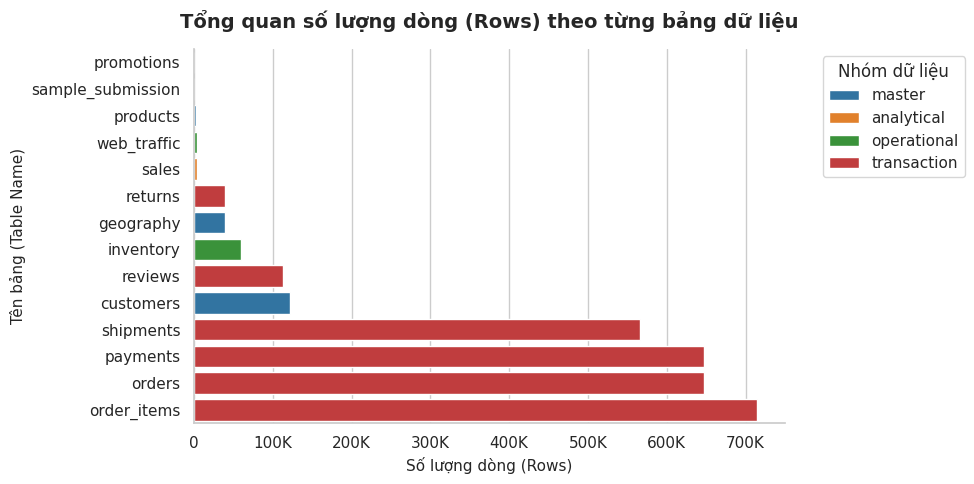

In [11]:
"""
Phần EDA: 1. Data Inventory
Mục tiêu cell: Vẽ số dòng của từng bảng để nhìn nhanh bảng nào lớn nhất và nhóm dữ liệu nào chiếm nhiều volume nhất.
"""

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Vẽ biểu đồ trực quan hóa số lượng dòng của từng bảng
plt.figure(figsize=(10, 5))
# Sắp xếp để bảng nhiều dòng nhất nằm ở trên cùng
plot_df = table_overview.sort_values("rows", ascending=True)

ax = sns.barplot(
    x="rows", 
    y="table_name", 
    hue="group", # Phân màu theo nhóm dữ liệu (Master, Transaction,...)
    data=plot_df, 
    palette="tab10",
    dodge=False
)

# Định dạng lại trục X thành dạng viết tắt (K, M) cho gọn
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))

plt.title("Tổng quan số lượng dòng (Rows) theo từng bảng dữ liệu", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Số lượng dòng (Rows)", fontsize=11)
plt.ylabel("Tên bảng (Table Name)", fontsize=11)
plt.legend(title="Nhóm dữ liệu", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Hiểu cấu trúc dữ liệu

Mục tiêu: hiểu từng cột thuộc loại gì để biết nên kiểm tra missing, duplicate, domain, numeric range hay date logic theo cách nào.

In [24]:
"""
Phần EDA: 2. Column Profiling
Mục tiêu cell: Tạo hồ sơ từng cột gồm semantic type, dtype, missing, unique và sample values để biết mỗi cột nên được kiểm tra theo cách nào.
"""

profile_rows = []
for table, df in tables.items():
    for col in df.columns:
        s = df[col]
        missing = int(s.isna().sum())
        profile_rows.append({
            "table_name": table,
            "column_name": col,
            "semantic_type": semantic_type(table, col, s),
            "pandas_dtype": str(s.dtype),
            "non_null_count": int(s.notna().sum()),
            "missing_count": missing,
            "missing_pct": round(missing / len(df) * 100, 3) if len(df) else 0,
            "unique_count": int(s.nunique(dropna=True)),
            "unique_pct": round(s.nunique(dropna=True) / len(df) * 100, 3) if len(df) else 0,
            #"sample_values": sample_values(s),
        })

column_profile_summary = pd.DataFrame(profile_rows).sort_values(["table_name", "column_name"])
display(column_profile_summary)

,table_name,column_name,semantic_type,pandas_dtype,non_null_count,missing_count,missing_pct,unique_count,unique_pct
6,customers,acquisition_channel,categorical_low_cardinality,object,121930,0,0.0,6,0.005
5,customers,age_group,categorical_low_cardinality,object,121930,0,0.0,5,0.004
2,customers,city,categorical_high_cardinality,object,121930,0,0.0,42,0.034
0,customers,customer_id,id,int64,121930,0,0.0,121930,100.000
4,customers,gender,categorical_low_cardinality,object,121930,0,0.0,3,0.002
...,...,...,...,...,...,...,...,...,...
89,web_traffic,date,date,datetime64[ns],3652,0,0.0,3652,100.000
92,web_traffic,page_views,numeric_continuous,int64,3652,0,0.0,3620,99.124
90,web_traffic,sessions,numeric_continuous,int64,3652,0,0.0,3447,94.387
95,web_traffic,traffic_source,categorical_low_cardinality,object,3652,0,0.0,6,0.164


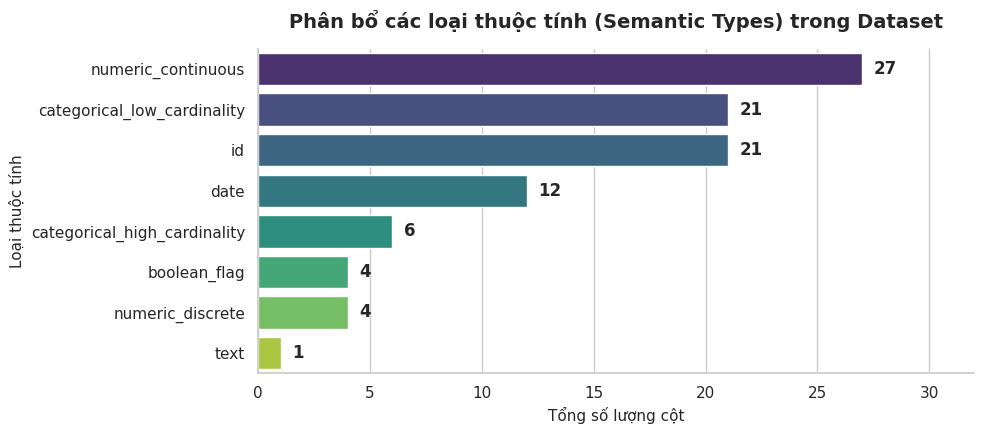

In [12]:
"""
Phần EDA: 2. Column Profiling
Mục tiêu cell: Tóm tắt số lượng cột theo semantic type để hiểu dataset thiên về ID, numeric, categorical, date hay text.
"""

# Biểu đồ phân bổ các thuộc tính trong dataset
type_counts = column_profile_summary["semantic_type"].value_counts().reset_index()
type_counts.columns = ["semantic_type", "count"]

plt.figure(figsize=(10, 4.5))
ax = sns.barplot(
    x="count", 
    y="semantic_type", 
    data=type_counts, 
    palette="viridis"
)

# Hiển thị số lượng cụ thể trên đầu mỗi thanh
for i, v in enumerate(type_counts["count"]):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.title("Phân bổ các loại thuộc tính (Semantic Types) trong Dataset", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tổng số lượng cột", fontsize=11)
plt.ylabel("Loại thuộc tính", fontsize=11)
plt.xlim(0, type_counts["count"].max() + 5)
plt.tight_layout()
plt.show()

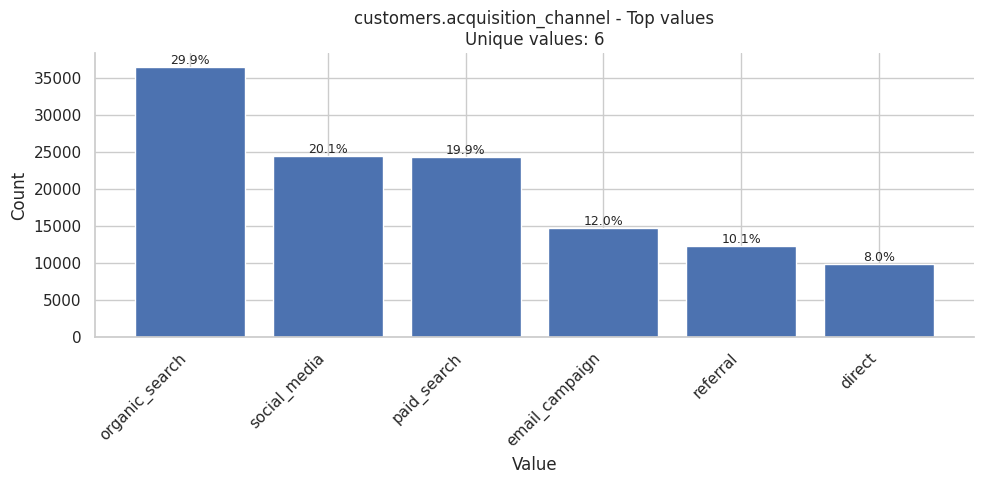

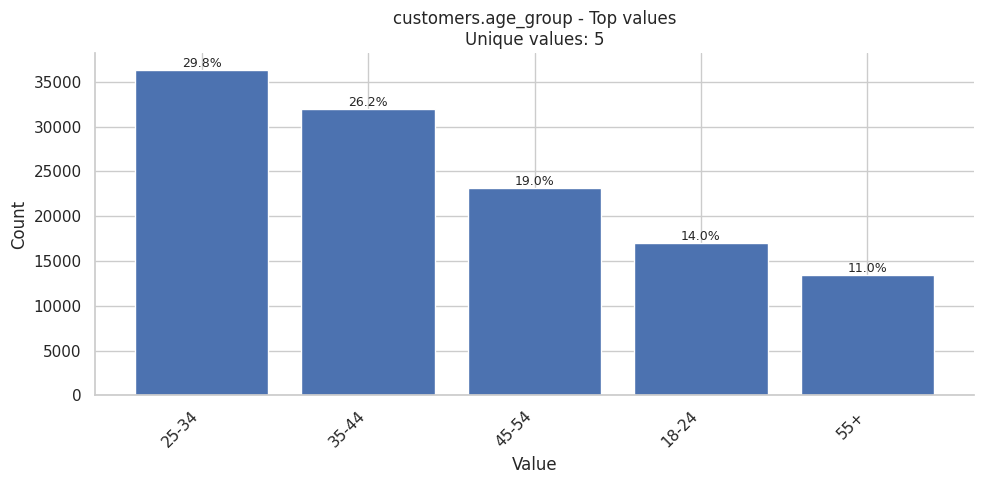

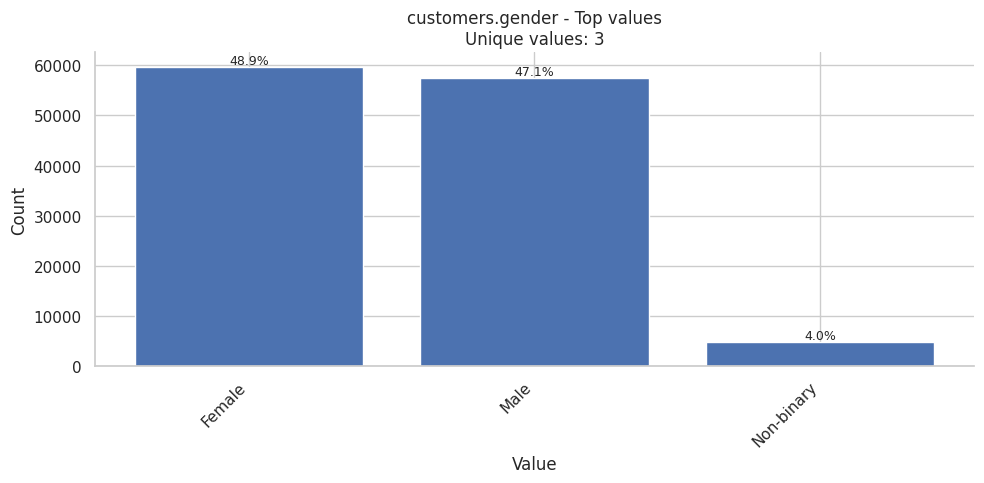

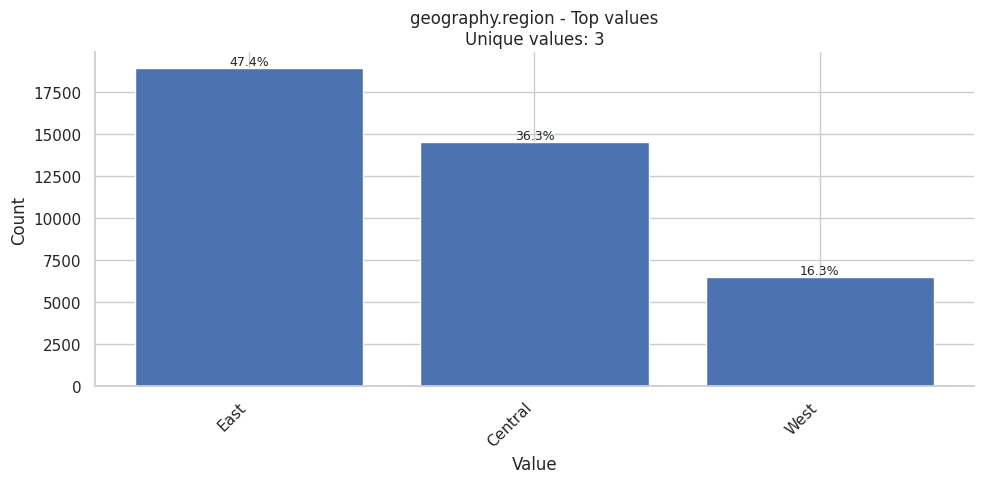

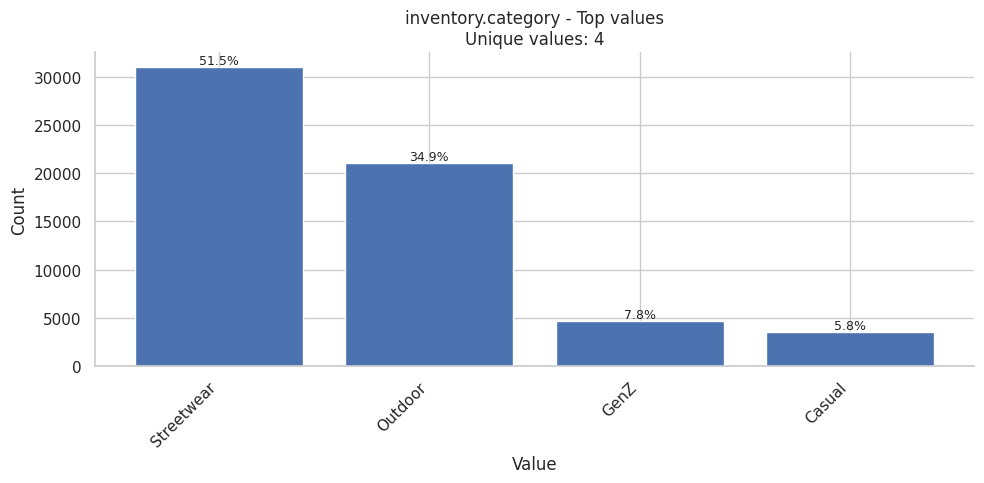

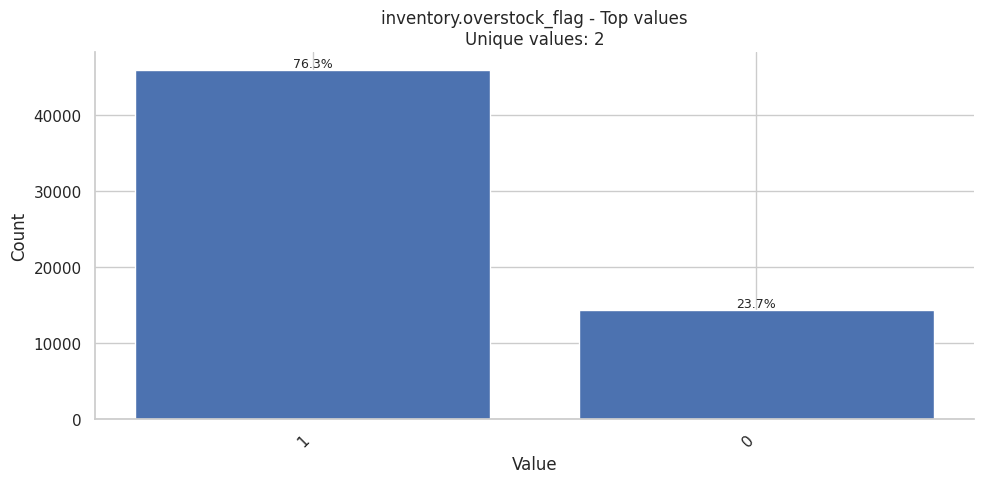

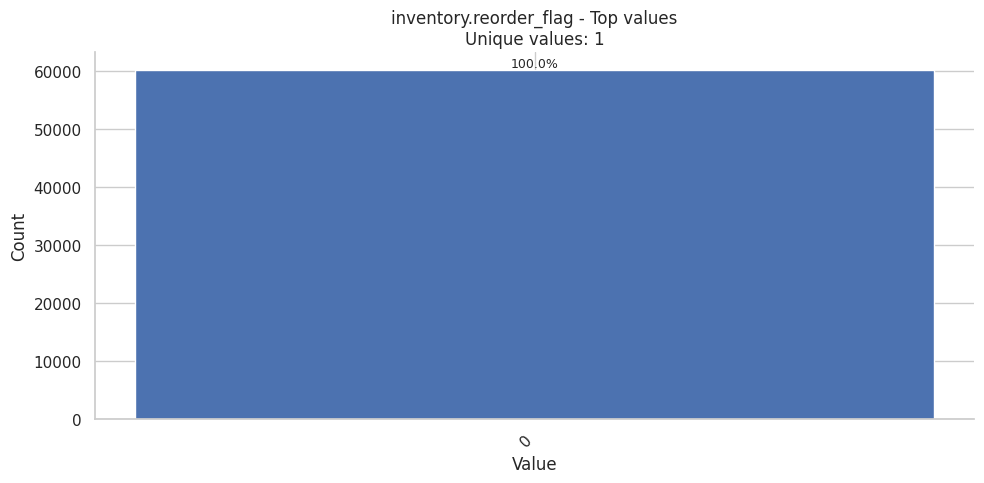

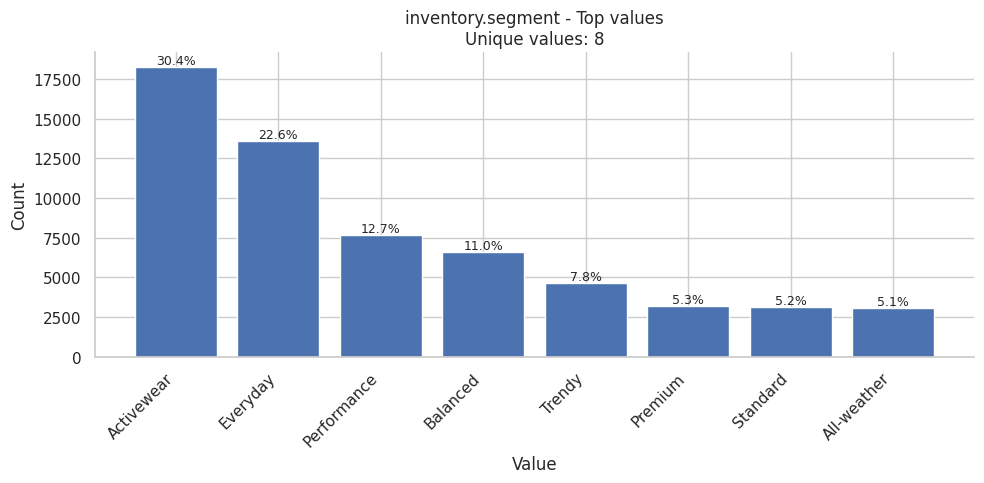

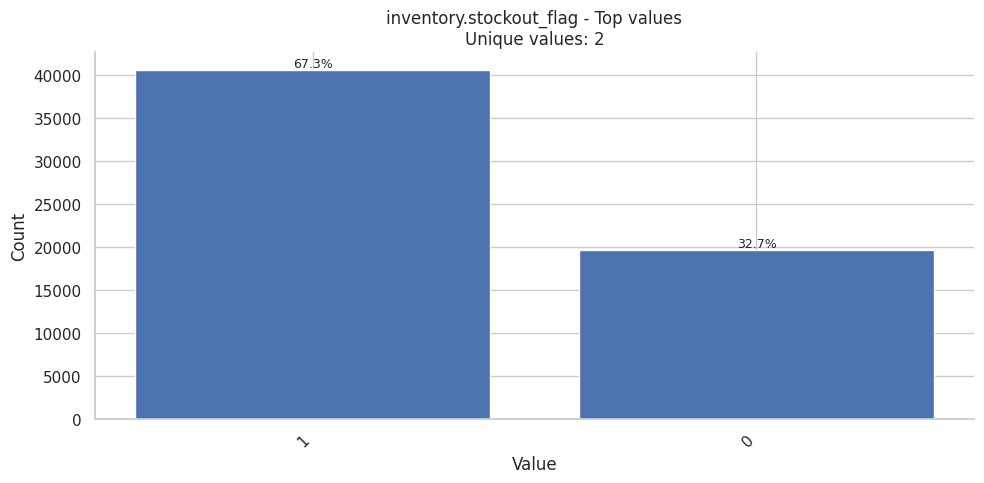

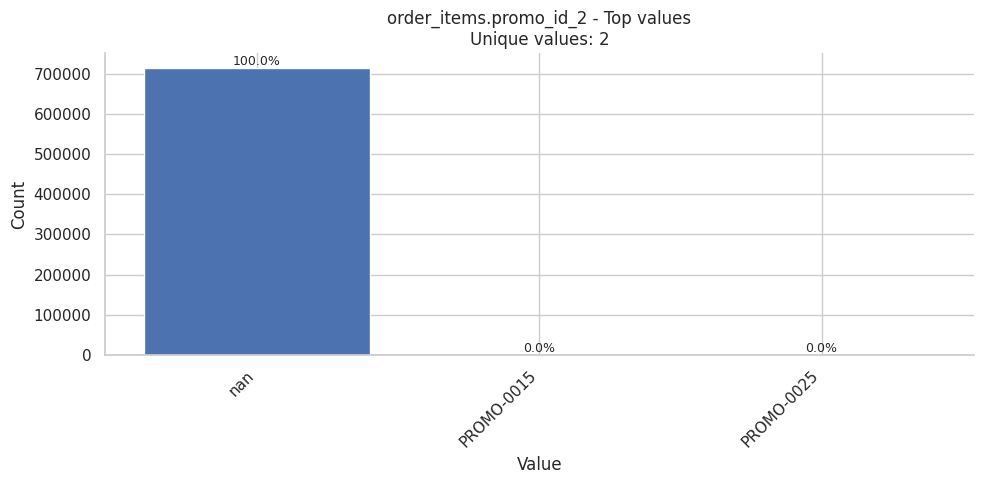

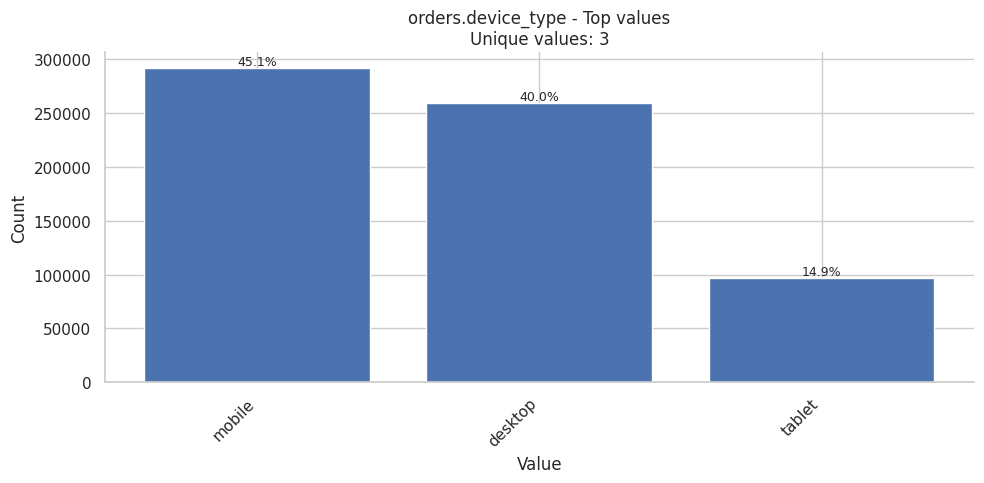

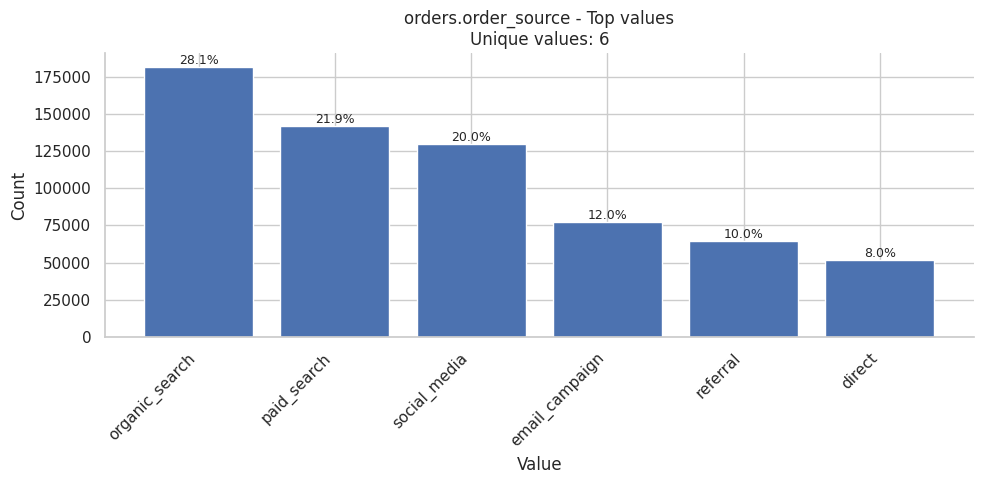

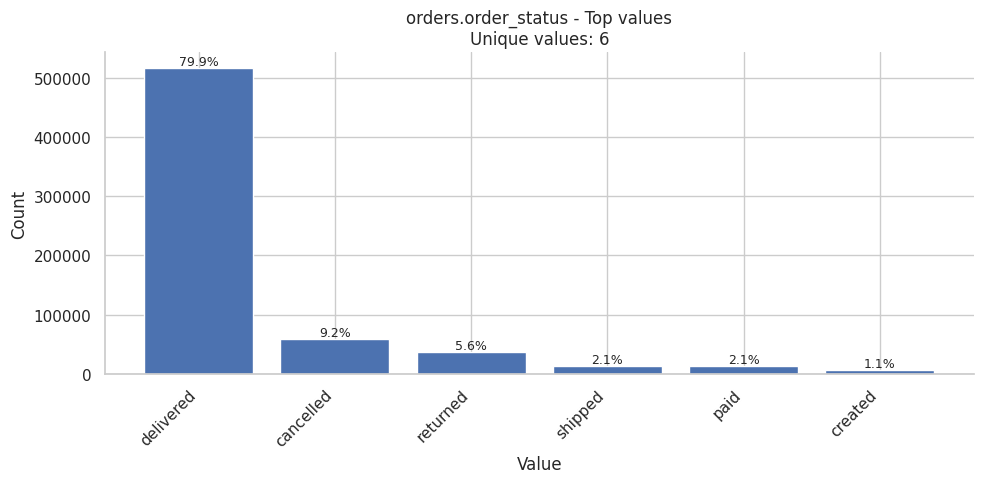

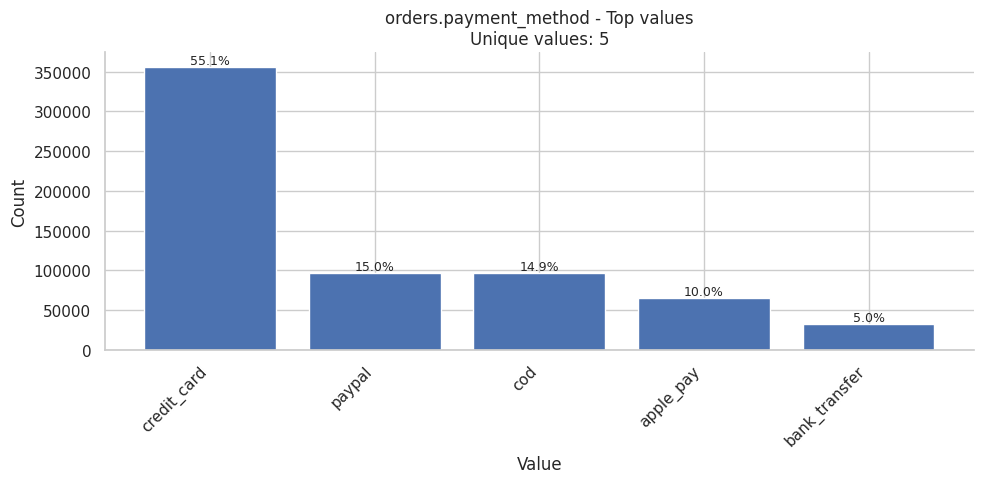

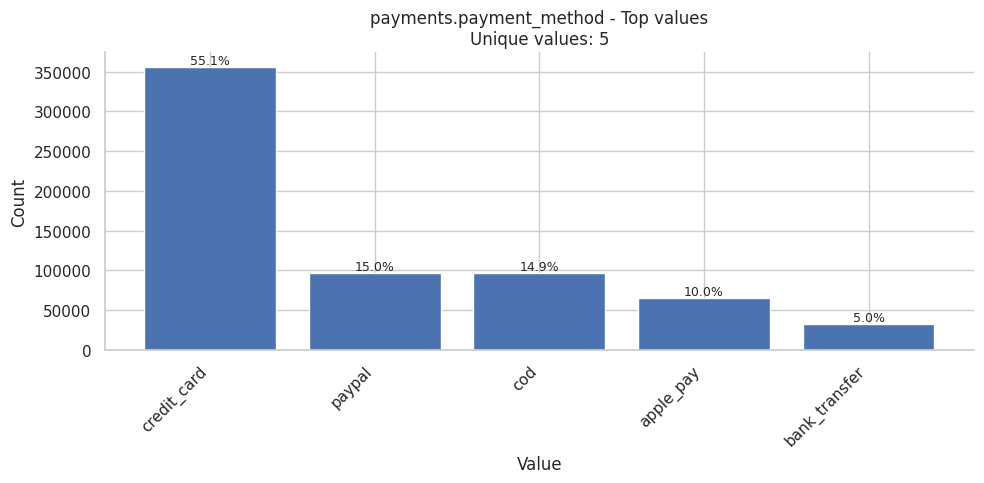

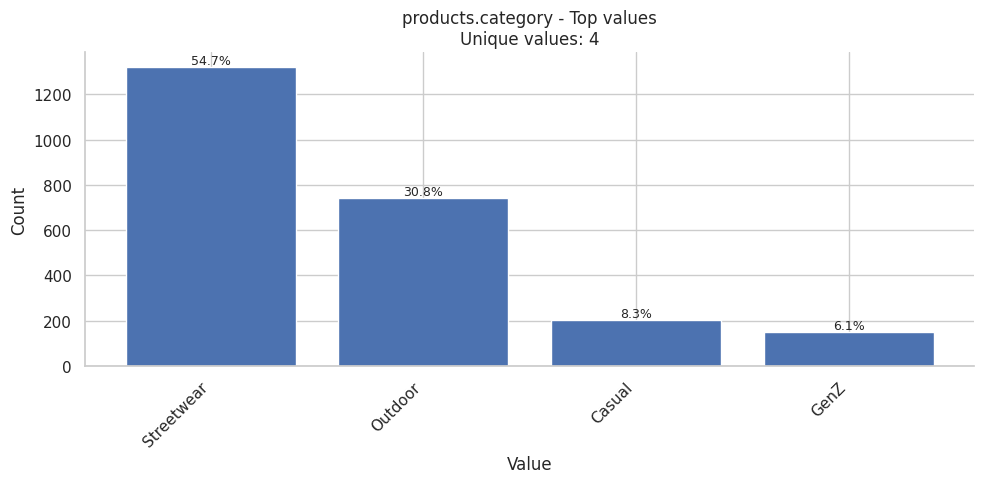

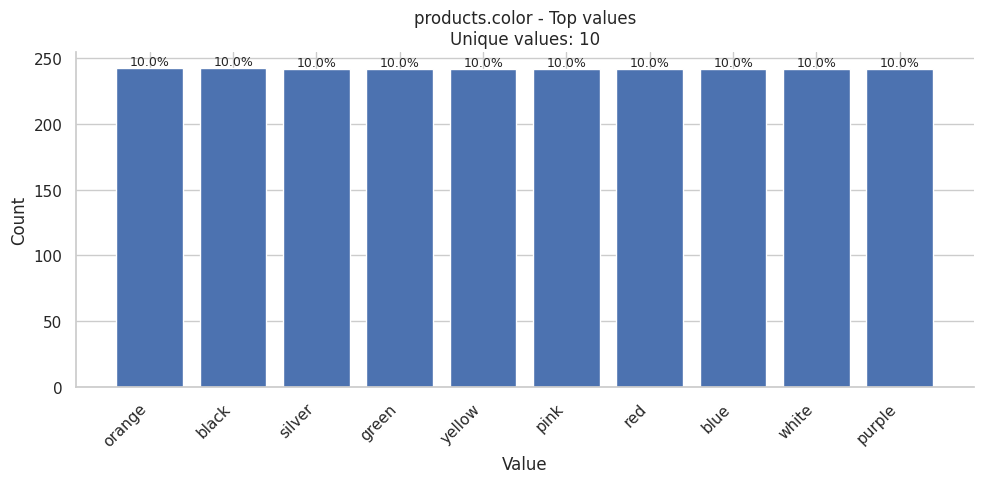

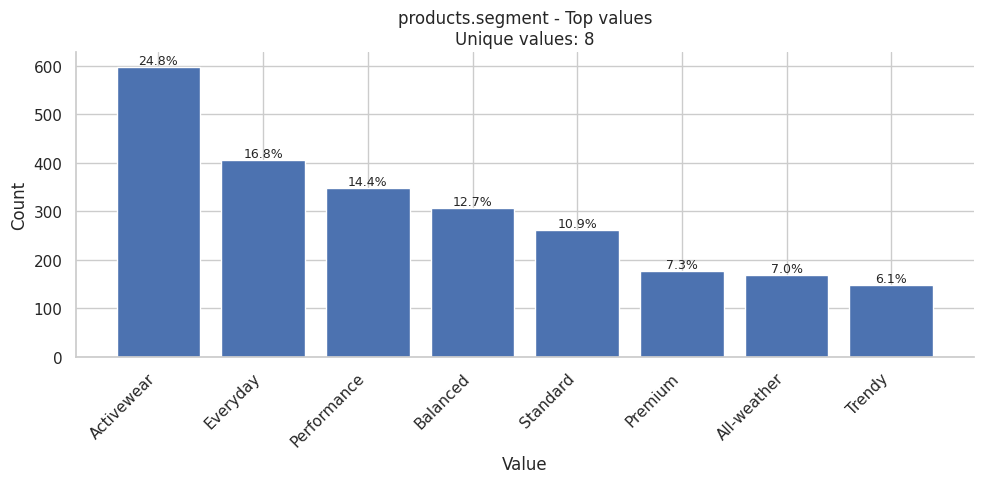

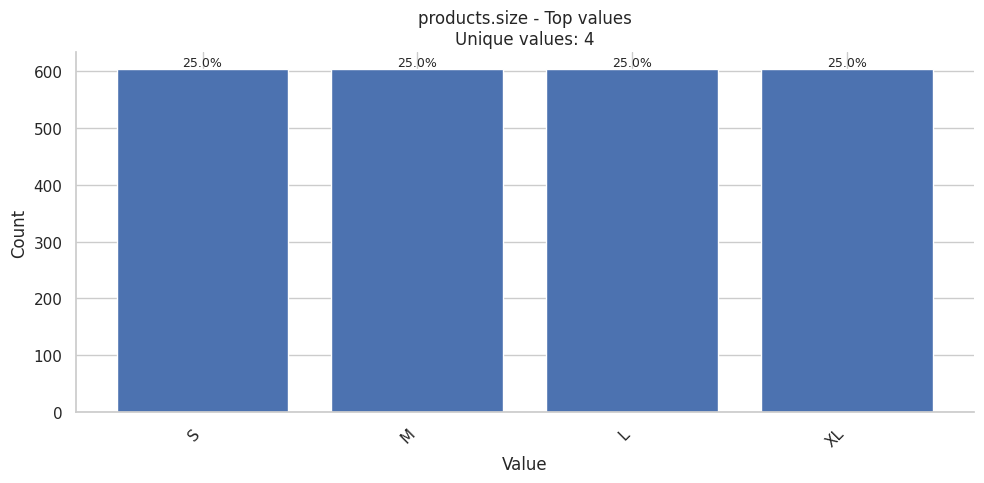

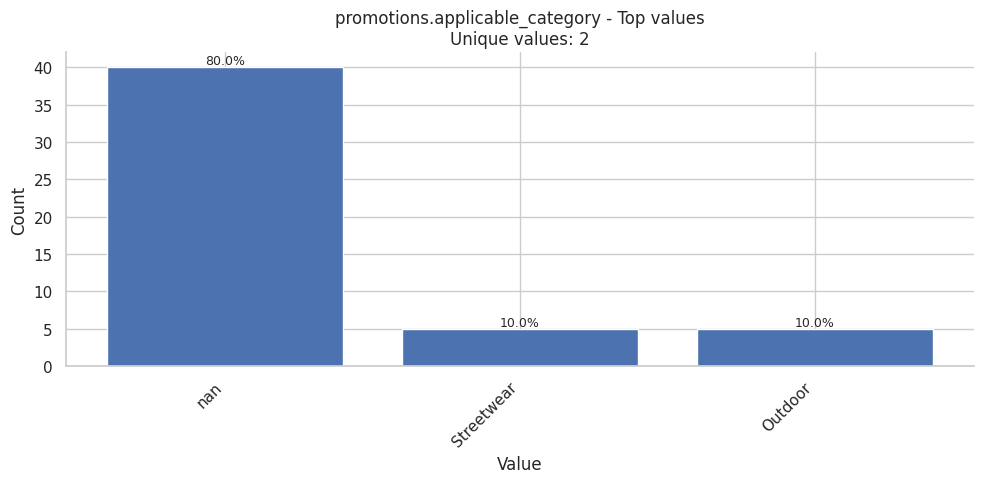

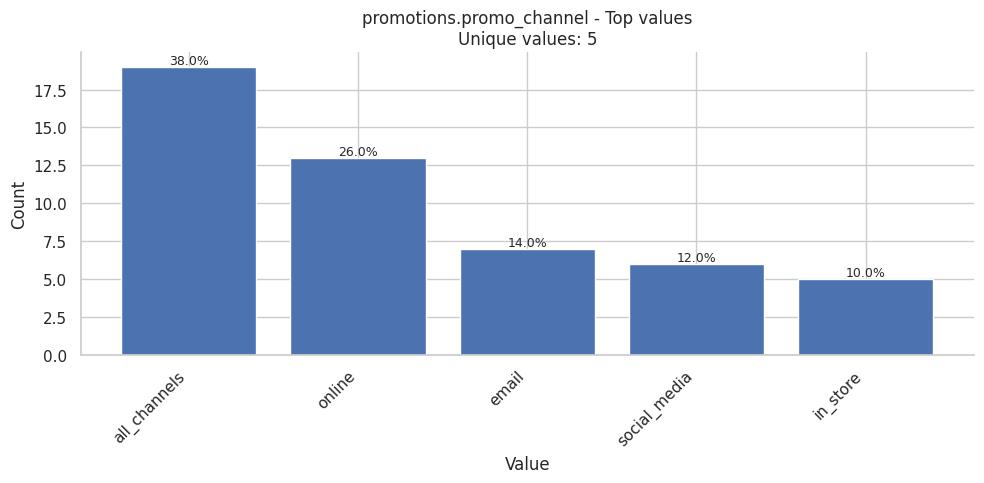

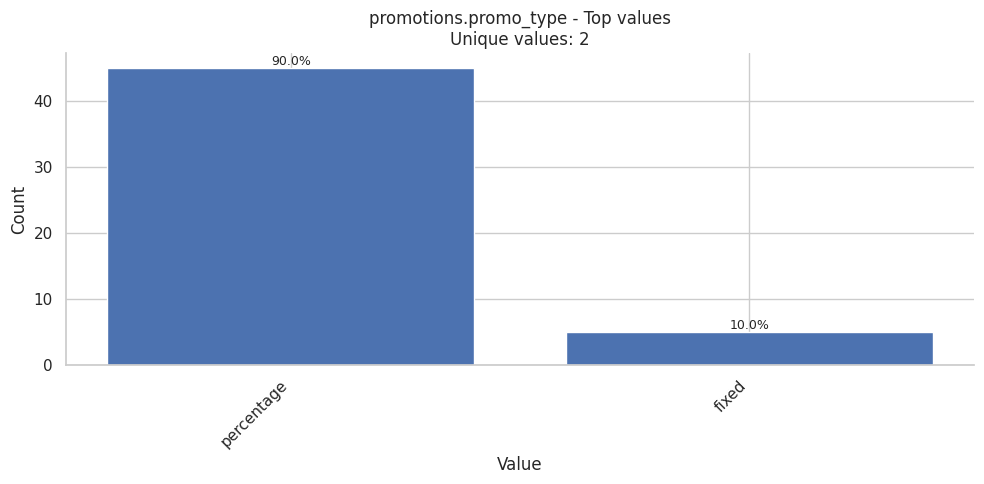

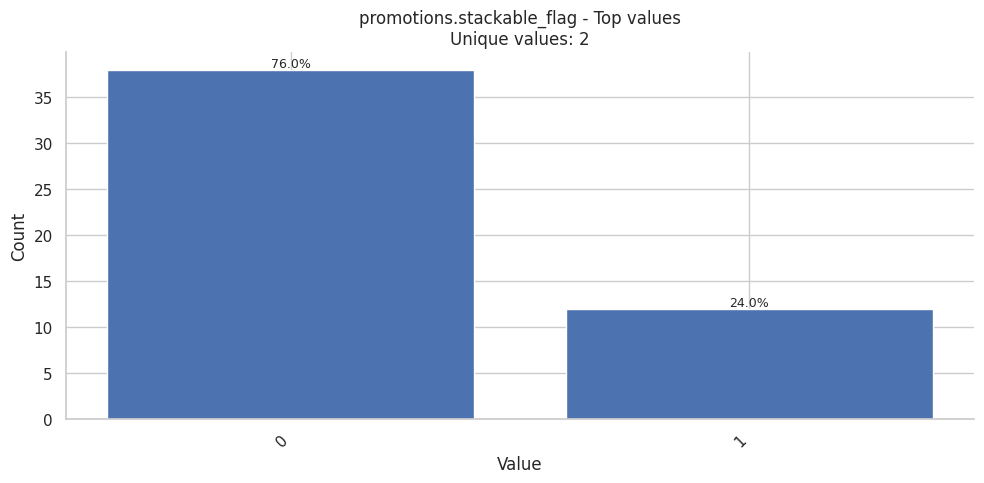

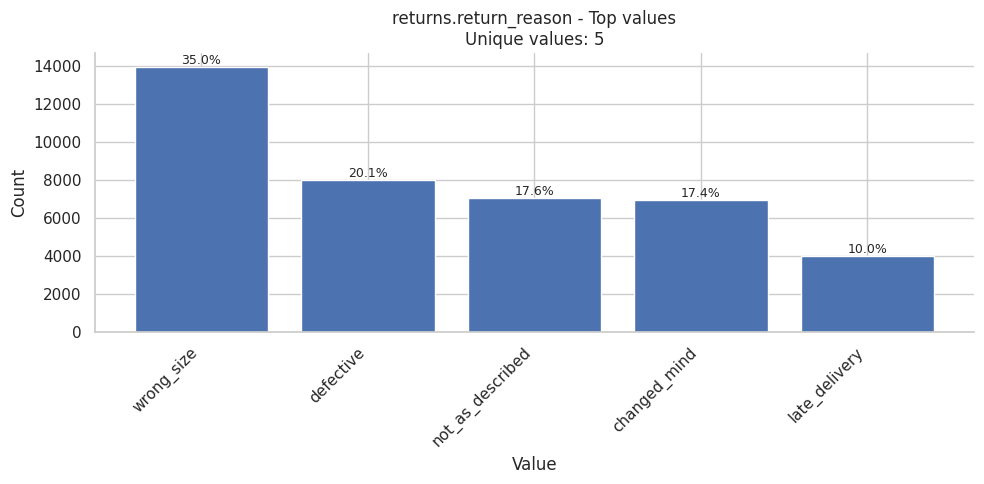

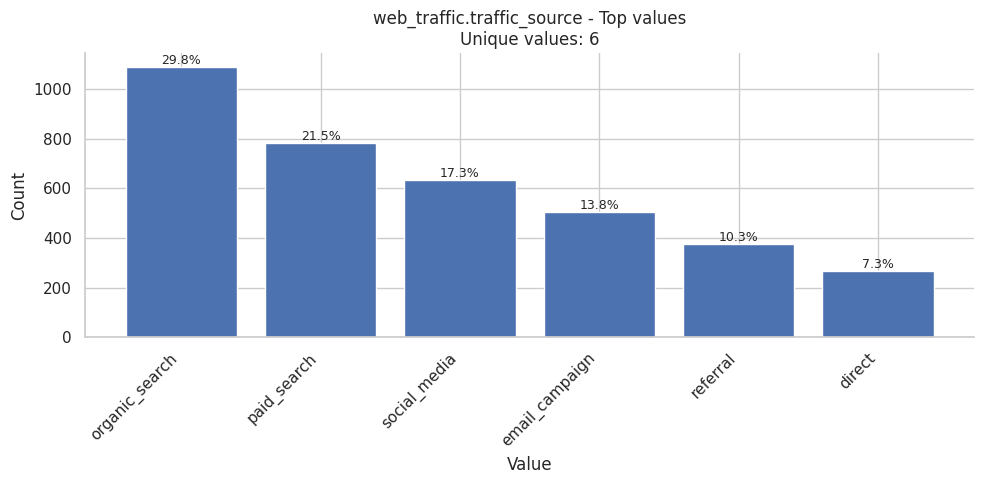

In [15]:
"""
Phần EDA: 2. Column Profiling
Mục tiêu cell: Hiển thị phân phối giá trị cho các cột categorical/boolean có domain nhỏ để phát hiện domain lệch, giá trị hiếm hoặc cách ghi không nhất quán.
"""

# phần  trâm giá trị unique trong cột dữ liệu
for _, row in column_profile_summary.iterrows():
    # Chỉ vẽ các cột categorical ít giá trị hoặc boolean
    if row["semantic_type"] not in ["categorical_low_cardinality", "boolean_flag"]:
        continue

    table = row["table_name"]
    col = row["column_name"]

    s = tables[table][col]

    # Đếm top 12 giá trị, bao gồm cả NaN
    counts = s.value_counts(dropna=False).head(12)

    # Đổi NaN thành chuỗi để hiện trên biểu đồ
    labels = counts.index.astype(str)
    values = counts.values
    percents = values / len(s) * 100

    plt.figure(figsize=(10, 5))

    bars = plt.bar(labels, values)

    plt.title(
        f"{table}.{col} - Top values\n"
        f"Unique values: {int(row['unique_count'])}"
    )
    plt.xlabel("Value")
    plt.ylabel("Count")

    plt.xticks(rotation=45, ha="right")

    # Ghi % lên đầu cột
    for bar, pct in zip(bars, percents):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

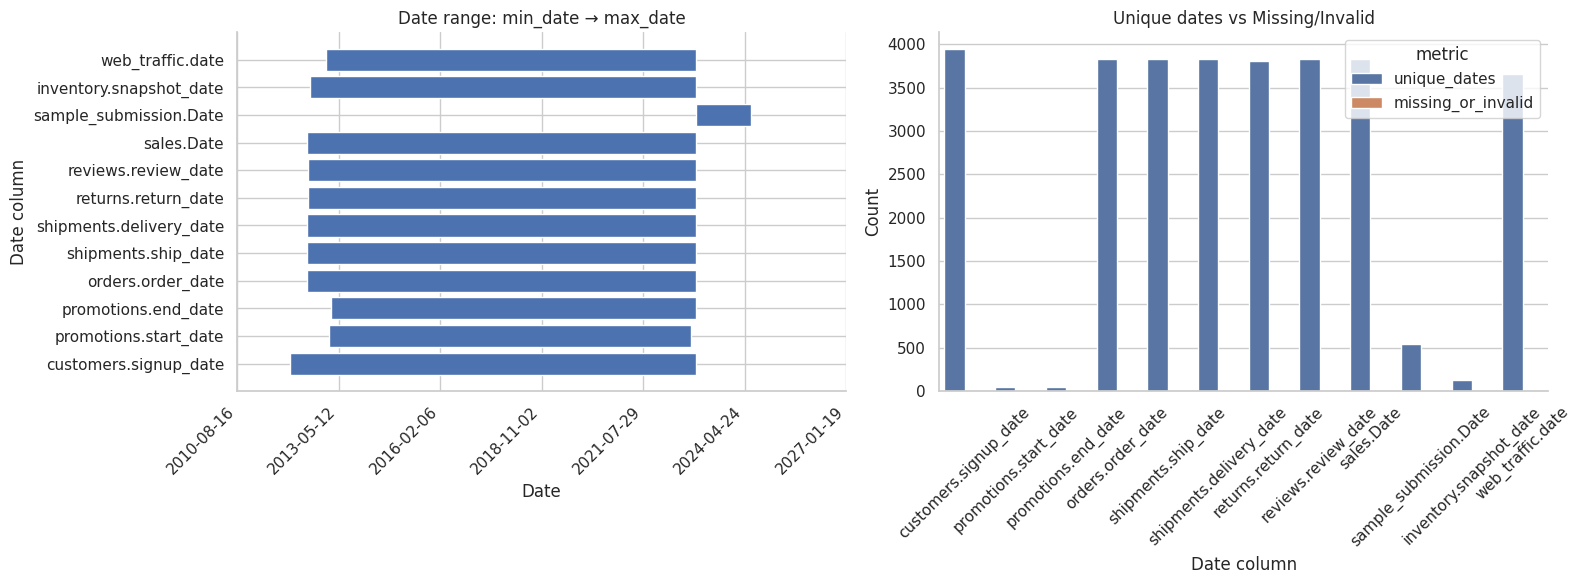

In [17]:
"""
Phần EDA: 2. Date Profiling
Mục tiêu cell: Tổng hợp min date, max date, số ngày unique và số dòng ngày lỗi/missing cho các cột thời gian quan trọng.
"""

date_range_summary = pd.DataFrame([
    {
        "field": f"{table}.{col}",
        "min_date": tables[table][col].min(),
        "max_date": tables[table][col].max(),
        "unique_dates": tables[table][col].dt.normalize().nunique(dropna=True),
        "missing_or_invalid": tables[table][col].isna().sum(),
        "missing_pct": tables[table][col].isna().mean() * 100
    }
    for table, cols in DATE_COLUMNS.items()
    if table in tables
    for col in cols
    if col in tables[table].columns
])

date_range_summary["duration_days"] = (
    date_range_summary["max_date"] - date_range_summary["min_date"]
).dt.days

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(date_range_summary) * 0.5)))

# 1) Date range: min_date -> max_date
axes[0].barh(
    date_range_summary["field"],
    date_range_summary["duration_days"],
    left=date_range_summary["min_date"].map(pd.Timestamp.toordinal)
)

axes[0].set_title("Date range: min_date → max_date")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Date column")

ticks = axes[0].get_xticks()
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(
    [pd.Timestamp.fromordinal(int(t)).strftime("%Y-%m-%d") for t in ticks if t > 0],
    rotation=45,
    ha="right"
)

# 2) Unique dates vs missing/invalid
plot_long = date_range_summary.melt(
    id_vars="field",
    value_vars=["unique_dates", "missing_or_invalid"],
    var_name="metric",
    value_name="count"
)

sns.barplot(
    data=plot_long,
    x="field",
    y="count",
    hue="metric",
    ax=axes[1]
)

axes[1].set_title("Unique dates vs Missing/Invalid")
axes[1].set_xlabel("Date column")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [25]:
"""
Phần EDA: 2. Key & Join Readiness
Mục tiêu cell: Kiểm tra primary key/candidate key theo grain từng bảng để biết bảng nào an toàn khi join và bảng nào có nguy cơ nhân dòng.
"""

key_rows = []
for table, keys in PRIMARY_KEYS.items():
    if table not in tables:
        continue
    df = tables[table]
    cols = [c for c in keys if c in df.columns]
    if not cols:
        continue
    duplicate_rows = int(df.duplicated(subset=cols).sum())
    key_rows.append({
        "table_name": table,
        "key_columns": ", ".join(cols),
        "rows": len(df),
        "unique_keys": int(df[cols].drop_duplicates().shape[0]),
        "duplicate_rows": duplicate_rows,
        "severity": "PASS" if duplicate_rows == 0 else "HIGH",
        "note": "safe key for this grain" if duplicate_rows == 0 else "check grain before joining",
    })
    
def highlight_high(row):
    return ['background-color: #fee2e2; color: #991b1b' if row['severity'] == 'HIGH' else '' for _ in row]
    
duplicate_key_summary = pd.DataFrame(key_rows).sort_values("duplicate_rows", ascending=False)
display(duplicate_key_summary.style.apply(highlight_high, axis=1))

,table_name,key_columns,rows,unique_keys,duplicate_rows,severity,note
5,order_items,"order_id, product_id",714669,714653,16,HIGH,check grain before joining
0,products,product_id,2412,2412,0,PASS,safe key for this grain
1,customers,customer_id,121930,121930,0,PASS,safe key for this grain
2,geography,zip,39948,39948,0,PASS,safe key for this grain
3,promotions,promo_id,50,50,0,PASS,safe key for this grain
4,orders,order_id,646945,646945,0,PASS,safe key for this grain
6,payments,order_id,646945,646945,0,PASS,safe key for this grain
7,shipments,order_id,566067,566067,0,PASS,safe key for this grain
8,returns,return_id,39939,39939,0,PASS,safe key for this grain
9,reviews,review_id,113551,113551,0,PASS,safe key for this grain


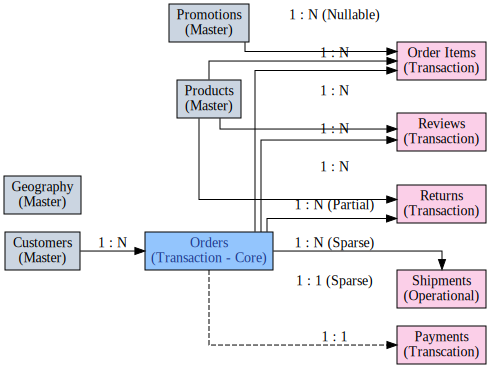

In [30]:
"""
Phần EDA: 2. Key & Join Readiness
Mục tiêu cell: Vẽ sơ đồ quan hệ bảng để người đọc thấy luồng join chính giữa master, transaction, operational và analytical data.
"""

import graphviz

# Khởi tạo sơ đồ dạng đồ thị có hướng (Directed Graph)
dot = graphviz.Digraph(comment='Data Model Relationships', graph_attr={'rankdir': 'LR', 'splines': 'ortho'})

# Định nghĩa các node (Các bảng dữ liệu trong hệ thống)
# Chia màu để phân biệt bảng Master (Kinh điển) và bảng Transaction (Giao dịch)
dot.node('customers', 'Customers\n(Master)', shape='box', style='filled', fillcolor='#cbd5e1')
dot.node('geography', 'Geography\n(Master)', shape='box', style='filled', fillcolor='#cbd5e1')
dot.node('products', 'Products\n(Master)', shape='box', style='filled', fillcolor='#cbd5e1')
dot.node('promotions', 'Promotions\n(Master)', shape='box', style='filled', fillcolor='#cbd5e1')

dot.node('orders', 'Orders\n(Transaction - Core)', shape='box', style='filled', fillcolor='#93c5fd', fontcolor='#1e3a8a')
dot.node('order_items', 'Order Items\n(Transaction)', shape='box', style='filled', fillcolor='#fbcfe8')
dot.node('payments', 'Payments\n(Transcation)', shape='box', style='filled', fillcolor='#fbcfe8')
dot.node('shipments', 'Shipments\n(Operational)', shape='box', style='filled', fillcolor='#fbcfe8')
dot.node('returns', 'Returns\n(Transaction)', shape='box', style='filled', fillcolor='#fbcfe8')
dot.node('reviews', 'Reviews\n(Transaction)', shape='box', style='filled', fillcolor='#fbcfe8')

# Vẽ các đường mũi tên thể hiện mối quan hệ (Parent -> Child)
dot.edge('customers', 'orders', label='1 : N')
dot.edge('products', 'order_items', label='1 : N')
dot.edge('products', 'returns', label='1 : N')
dot.edge('products', 'reviews', label='1 : N')

dot.edge('orders', 'order_items', label='1 : N')
dot.edge('orders', 'payments', label='1 : 1', style='dashed')
dot.edge('orders', 'shipments', label='1 : 1 (Sparse)')
dot.edge('orders', 'returns', label='1 : N (Sparse)')
dot.edge('orders', 'reviews', label='1 : N (Partial)')
dot.edge('promotions', 'order_items', label='1 : N (Nullable)')

# Hiển thị sơ đồ ngay trong Jupyter/Kaggle Notebook
dot

## 3. Kiểm tra chất lượng dữ liệu

Mục tiêu: xác định dữ liệu có đủ tin cậy để phân tích tiếp không. Các bảng dưới đây không nhằm sửa dữ liệu ngay, mà để ghi rõ issue, severity và quyết định xử lý.

In [31]:
"""
Phần EDA: 3. Missing Values
Mục tiêu cell: Tính missing cho từng cột và diễn giải missing là hợp lý nghiệp vụ hay cần điều tra trước khi phân tích.
"""

def classify_missing(table, column, missing_count, missing_pct):
    if missing_count == 0:
        return "complete", "Pass", "No missing"
    if (table, column) in {("order_items", "promo_id"), ("order_items", "promo_id_2")}:
        return "business-valid missing", "Keep as is", "Missing means no promotion"
    if table == "sample_submission" and column in ["Revenue", "COGS"]:
        return "target placeholder", "Keep as is", "Forecast target is intentionally blank"
    if column.endswith("_id") or column in ["Date", "date", "order_date", "Revenue", "COGS"]:
        return "critical field missing", "Investigate later", "Can affect joins or core metrics"
    if missing_pct >= 50:
        return "high missing", "Investigate later", "Need business meaning before use"
    return "low/medium missing", "Flag only", "Document before using this feature"

missing_rows = []
for table, df in tables.items():
    for col in df.columns:
        missing = int(df[col].isna().sum())
        pct = round(missing / len(df) * 100, 3) if len(df) else 0
        interpretation, action, reason = classify_missing(table, col, missing, pct)
        if missing > 0:
            missing_rows.append({
                "table_name": table,
                "column": col,
                "missing_count": missing,
                "missing_pct": pct,
                "interpretation": interpretation,
                "action": action,
                "reason": reason,
            })

missing_summary = pd.DataFrame(missing_rows).sort_values("missing_pct", ascending=False)
display(missing_summary)

,table_name,column,missing_count,missing_pct,interpretation,action,reason
1,order_items,promo_id_2,714463,99.971,business-valid missing,Keep as is,Missing means no promotion
2,promotions,applicable_category,40,80.000,high missing,Investigate later,Need business meaning before use
0,order_items,promo_id,438353,61.337,business-valid missing,Keep as is,Missing means no promotion


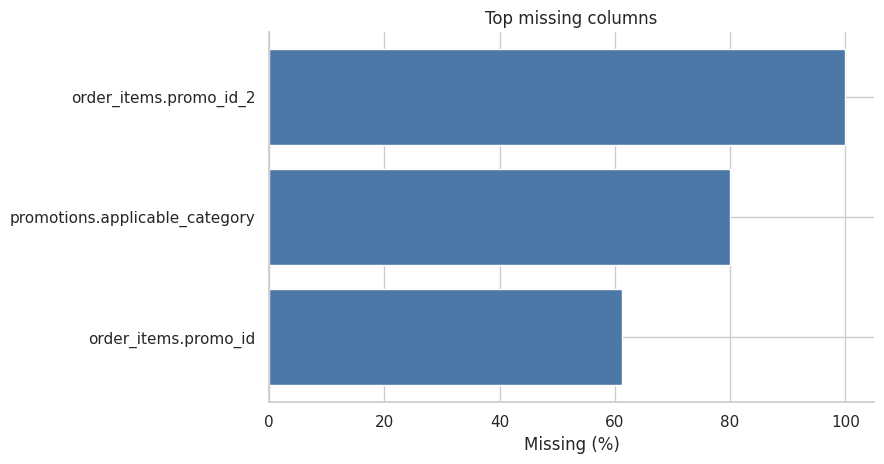

In [51]:
"""
Phần EDA: 3. Missing Values
Mục tiêu cell: Vẽ các cột có tỷ lệ missing cao nhất để ưu tiên giải thích/xử lý trong data quality report.
"""

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = missing_summary.sort_values("missing_pct", ascending=True)
ax.barh(plot_df["table_name"] + "." + plot_df["column"], plot_df["missing_pct"], color="#4c78a8")
ax.set_title("Top missing columns")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [32]:
"""
Phần EDA: 3. Duplicate Checks
Mục tiêu cell: Kiểm tra duplicate full row ở từng bảng để phát hiện dữ liệu bị lặp nguyên dòng.
"""

duplicate_full_summary = pd.DataFrame([
    {
        "table_name": name,
        "rows": len(df),
        "duplicate_full_rows": int(df.duplicated().sum()),
        "duplicate_full_pct": round(df.duplicated().mean() * 100, 4),
        "decision": "Pass" if int(df.duplicated().sum()) == 0 else "Investigate later",
    }
    for name, df in tables.items()
]).sort_values("duplicate_full_rows", ascending=False)

display(duplicate_full_summary)

,table_name,rows,duplicate_full_rows,duplicate_full_pct,decision
0,customers,121930,0,0.0,Pass
1,geography,39948,0,0.0,Pass
2,inventory,60247,0,0.0,Pass
3,order_items,714669,0,0.0,Pass
4,orders,646945,0,0.0,Pass
5,payments,646945,0,0.0,Pass
6,products,2412,0,0.0,Pass
7,promotions,50,0,0.0,Pass
8,returns,39939,0,0.0,Pass
9,reviews,113551,0,0.0,Pass



**Kiểm tra logic hợp lệ
1. Ngày đặt hàng > ngày ship
2.   giá tiền <= 0
3. date start > date end**


In [33]:
"""
Phần EDA: 3. Time Logic Checks
Mục tiêu cell: Kiểm tra thứ tự thời gian giữa các bảng như signup <= order, order <= ship/delivery/return/review và promotion start <= end.
"""

time_rules = []
if {"orders", "customers"}.issubset(tables):
    tmp = tables["orders"][["order_id", "customer_id", "order_date"]].merge(
        tables["customers"][["customer_id", "signup_date"]], on="customer_id", how="left"
    )
    time_rules.append(rule_summary("signup_date <= order_date", tmp, tmp["signup_date"] > tmp["order_date"], "HIGH", "customer signs up after order"))

if {"orders", "shipments"}.issubset(tables):
    tmp = tables["shipments"].merge(tables["orders"][["order_id", "order_date"]], on="order_id", how="left")
    time_rules.append(rule_summary("order_date <= ship_date", tmp, tmp["order_date"] > tmp["ship_date"], "HIGH", "ship before order"))
    time_rules.append(rule_summary("ship_date <= delivery_date", tmp, tmp["delivery_date"].notna() & (tmp["ship_date"] > tmp["delivery_date"]), "HIGH", "delivery before shipping"))

if {"orders", "returns"}.issubset(tables):
    tmp = tables["returns"].merge(tables["orders"][["order_id", "order_date"]], on="order_id", how="left")
    time_rules.append(rule_summary("order_date <= return_date", tmp, tmp["order_date"] > tmp["return_date"], "HIGH", "return before order"))

if {"orders", "reviews"}.issubset(tables):
    tmp = tables["reviews"].merge(tables["orders"][["order_id", "order_date"]], on="order_id", how="left")
    time_rules.append(rule_summary("order_date <= review_date", tmp, tmp["order_date"] > tmp["review_date"], "HIGH", "review before order"))

if "promotions" in tables:
    p = tables["promotions"]
    time_rules.append(rule_summary("start_date <= end_date", p, p["start_date"] > p["end_date"], "HIGH", "promotion ends before start"))

time_logic_issues = pd.DataFrame(time_rules)
display(time_logic_issues)

,rule,checked_rows,issue_count,issue_pct,severity,note
0,signup_date <= order_date,646945,477453,73.8012,HIGH,customer signs up after order
1,order_date <= ship_date,566067,0,0.0000,PASS,pass
2,ship_date <= delivery_date,566067,0,0.0000,PASS,pass
3,order_date <= return_date,39939,0,0.0000,PASS,pass
4,order_date <= review_date,113551,0,0.0000,PASS,pass
5,start_date <= end_date,50,0,0.0000,PASS,pass


In [34]:
"""
Phần EDA: 3. Business Rule Checks
Mục tiêu cell: Kiểm tra các rule nghiệp vụ cơ bản như giá trị dương, discount không vượt gross value, rating trong [1,5], tỷ lệ inventory trong [0,1].
"""

business_rules = []
checks = [
    ("products", "products.price > 0", lambda d: d["price"] <= 0),
    ("products", "products.cogs >= 0", lambda d: d["cogs"] < 0),
    ("products", "products.price >= cogs", lambda d: d["price"] < d["cogs"]),
    ("order_items", "quantity > 0", lambda d: d["quantity"] <= 0),
    ("order_items", "unit_price > 0", lambda d: d["unit_price"] <= 0),
    ("order_items", "discount_amount >= 0", lambda d: d["discount_amount"] < 0),
    ("order_items", "discount <= quantity * unit_price", lambda d: d["discount_amount"] > d["quantity"] * d["unit_price"]),
    ("payments", "payment_value >= 0", lambda d: d["payment_value"] < 0),
    ("shipments", "shipping_fee >= 0", lambda d: d["shipping_fee"] < 0),
    ("returns", "return_quantity > 0", lambda d: d["return_quantity"] <= 0),
    ("returns", "refund_amount >= 0", lambda d: d["refund_amount"] < 0),
    ("reviews", "rating between 1 and 5", lambda d: (d["rating"] < 1) | (d["rating"] > 5)),
    ("sales", "Revenue > 0", lambda d: d["Revenue"] <= 0),
    ("sales", "COGS > 0", lambda d: d["COGS"] <= 0),
    ("inventory", "stock_on_hand >= 0", lambda d: d["stock_on_hand"] < 0),
    ("inventory", "units_received >= 0", lambda d: d["units_received"] < 0),
    ("inventory", "units_sold >= 0", lambda d: d["units_sold"] < 0),
    ("inventory", "stockout_days >= 0", lambda d: d["stockout_days"] < 0),
    ("inventory", "fill_rate between 0 and 1", lambda d: (d["fill_rate"] < 0) | (d["fill_rate"] > 1)),
    ("inventory", "sell_through_rate between 0 and 1", lambda d: (d["sell_through_rate"] < 0) | (d["sell_through_rate"] > 1)),
]

for table, name, fn in checks:
    if table in tables:
        business_rules.append(rule_summary(name, tables[table], fn(tables[table]), "HIGH", "violates business rule"))

business_rule_issues = pd.DataFrame(business_rules)
display(business_rule_issues)

,rule,checked_rows,issue_count,issue_pct,severity,note
0,products.price > 0,2412,0,0.0,PASS,pass
1,products.cogs >= 0,2412,0,0.0,PASS,pass
2,products.price >= cogs,2412,0,0.0,PASS,pass
3,quantity > 0,714669,0,0.0,PASS,pass
4,unit_price > 0,714669,0,0.0,PASS,pass
5,discount_amount >= 0,714669,0,0.0,PASS,pass
6,discount <= quantity * unit_price,714669,0,0.0,PASS,pass
7,payment_value >= 0,646945,0,0.0,PASS,pass
8,shipping_fee >= 0,566067,0,0.0,PASS,pass
9,return_quantity > 0,39939,0,0.0,PASS,pass


In [35]:
"""
Phần EDA: 3. Referential Integrity
Mục tiêu cell: Kiểm tra khóa ngoại có trỏ được về khóa chính hay không để phát hiện orphan records trước khi join.
"""

fk_checks = [
    ("orders", "customer_id", "customers", "customer_id", False),
    ("orders", "zip", "geography", "zip", False),
    ("order_items", "order_id", "orders", "order_id", False),
    ("order_items", "product_id", "products", "product_id", False),
    ("order_items", "promo_id", "promotions", "promo_id", True),
    ("order_items", "promo_id_2", "promotions", "promo_id", True),
    ("payments", "order_id", "orders", "order_id", False),
    ("shipments", "order_id", "orders", "order_id", False),
    ("returns", "order_id", "orders", "order_id", False),
    ("returns", "product_id", "products", "product_id", False),
    ("reviews", "order_id", "orders", "order_id", False),
    ("reviews", "product_id", "products", "product_id", False),
    ("inventory", "product_id", "products", "product_id", False),
]

fk_rows = []
for child, fk, parent, pk, nullable in fk_checks:
    child_df = tables[child]
    parent_keys = set(tables[parent][pk].dropna())
    check_df = child_df[child_df[fk].notna()] if nullable else child_df
    orphan = ~check_df[fk].isin(parent_keys)
    fk_rows.append({
        "child_table": child,
        "fk_column": fk,
        "parent_table": parent,
        "pk_column": pk,
        "checked_rows": len(check_df),
        "orphan_rows": int(orphan.sum()),
        "orphan_pct": round(orphan.mean() * 100, 4) if len(check_df) else 0,
        "status": "PASS" if int(orphan.sum()) == 0 else "FAIL",
        "note": "nullable FK checked only when non-null" if nullable else "required FK",
    })

relationship_fk_summary = pd.DataFrame(fk_rows)
display(relationship_fk_summary)

,child_table,fk_column,parent_table,pk_column,checked_rows,orphan_rows,orphan_pct,status,note
0,orders,customer_id,customers,customer_id,646945,0,0.0,PASS,required FK
1,orders,zip,geography,zip,646945,0,0.0,PASS,required FK
2,order_items,order_id,orders,order_id,714669,0,0.0,PASS,required FK
3,order_items,product_id,products,product_id,714669,0,0.0,PASS,required FK
4,order_items,promo_id,promotions,promo_id,276316,0,0.0,PASS,nullable FK checked only when non-null
5,order_items,promo_id_2,promotions,promo_id,206,0,0.0,PASS,nullable FK checked only when non-null
6,payments,order_id,orders,order_id,646945,0,0.0,PASS,required FK
7,shipments,order_id,orders,order_id,566067,0,0.0,PASS,required FK
8,returns,order_id,orders,order_id,39939,0,0.0,PASS,required FK
9,returns,product_id,products,product_id,39939,0,0.0,PASS,required FK


In [36]:
"""
Phần EDA: 3. Order Lifecycle Checks
Mục tiêu cell: Tóm tắt mỗi order_status có payment, shipment, return, review với tỷ lệ bao nhiêu để hiểu vòng đời đơn hàng.
"""

orders = tables["orders"]
base = orders[["order_id", "order_status"]].copy()
for name, df in {
    "payment": tables["payments"],
    "shipment": tables["shipments"],
    "return": tables["returns"],
    "review": tables["reviews"],
}.items():
    ids = df[["order_id"]].drop_duplicates().assign(**{f"has_{name}": True})
    base = base.merge(ids, on="order_id", how="left")

flag_cols = ["has_payment", "has_shipment", "has_return", "has_review"]
base[flag_cols] = base[flag_cols].fillna(False)
order_lifecycle_summary = (
    base.groupby("order_status")
    .agg(
        orders=("order_id", "nunique"),
        has_payment_pct=("has_payment", "mean"),
        has_shipment_pct=("has_shipment", "mean"),
        has_return_pct=("has_return", "mean"),
        has_review_pct=("has_review", "mean"),
    )
    .reset_index()
)
for col in flag_cols:
    pct_col = col + "_pct"
    order_lifecycle_summary[pct_col] = (order_lifecycle_summary[pct_col] * 100).round(2)

display(order_lifecycle_summary)

,order_status,orders,has_payment_pct,has_shipment_pct,has_return_pct,has_review_pct
0,cancelled,59462,100.0,0.00,0.00,0.00
1,created,7275,100.0,0.00,0.00,0.00
2,delivered,516716,100.0,99.90,0.00,21.55
3,paid,13577,100.0,0.00,0.00,0.00
4,returned,36142,100.0,99.92,99.78,0.00
5,shipped,13773,100.0,99.92,0.00,0.00


In [45]:
"""
Phần EDA: 3. Order Lifecycle Checks
Mục tiêu cell: Flag các mâu thuẫn vòng đời đơn hàng như cancelled nhưng có shipment hoặc returned nhưng thiếu return record.
"""

issue_rules = [
    (
        "Đơn đã hủy nhưng vẫn có dữ liệu giao hàng", 
        (base["order_status"] == "cancelled") & base["has_shipment"], 
        "HIGH", 
        "Trạng thái hủy đơn mâu thuẫn với việc đã xuất kho vận chuyển."
    ),
    (
        "Đơn báo trả hàng nhưng thiếu chi tiết trong bảng Returns", 
        (base["order_status"] == "returned") & ~base["has_return"], 
        "HIGH", 
        "Trạng thái là 'returned' nhưng không tìm thấy bản ghi thông tin trả hàng."
    ),
    (
        "Đơn báo trả hàng nhưng hệ thống chưa từng giao đi", 
        (base["order_status"] == "returned") & ~base["has_shipment"], 
        "HIGH", 
        "Đơn hàng phải được giao đi thành công thì mới có thể phát sinh trả hàng."
    ),
    (
        "Đơn đã giao thành công nhưng thiếu thông tin vận chuyển", 
        (base["order_status"] == "delivered") & ~base["has_shipment"], 
        "MEDIUM", 
        "Thiếu dòng dữ liệu tracking vận chuyển dù đơn đã chuyển sang trạng thái delivered."
    ),
    (
        "Đơn mới tạo/mới thanh toán mà đã có log vận chuyển", 
        base["order_status"].isin(["created", "paid"]) & base["has_shipment"], 
        "MEDIUM", 
        "Quy trình bị nhảy bước, đơn chưa xử lý xong đã có thông tin giao hàng."
    ),
]
order_lifecycle_issues = pd.DataFrame([
    {
        "rule": rule,
        "issue_count": int(mask.sum()),
        "issue_pct": round(mask.mean() * 100, 4),
        "severity": "PASS" if int(mask.sum()) == 0 else severity,
        "note": "pass" if int(mask.sum()) == 0 else note,
    }
    for rule, mask, severity, note in issue_rules
])

display(order_lifecycle_issues)

,rule,issue_count,issue_pct,severity,note
0,Đơn đã hủy nhưng vẫn có dữ liệu giao hàng,0,0.0000,PASS,pass
1,Đơn báo trả hàng nhưng thiếu chi tiết trong bả...,80,0.0124,HIGH,Trạng thái là 'returned' nhưng không tìm thấy ...
2,Đơn báo trả hàng nhưng hệ thống chưa từng giao đi,29,0.0045,HIGH,Đơn hàng phải được giao đi thành công thì mới ...
3,Đơn đã giao thành công nhưng thiếu thông tin v...,524,0.0810,MEDIUM,Thiếu dòng dữ liệu tracking vận chuyển dù đơn ...
4,Đơn mới tạo/mới thanh toán mà đã có log vận ch...,0,0.0000,PASS,pass


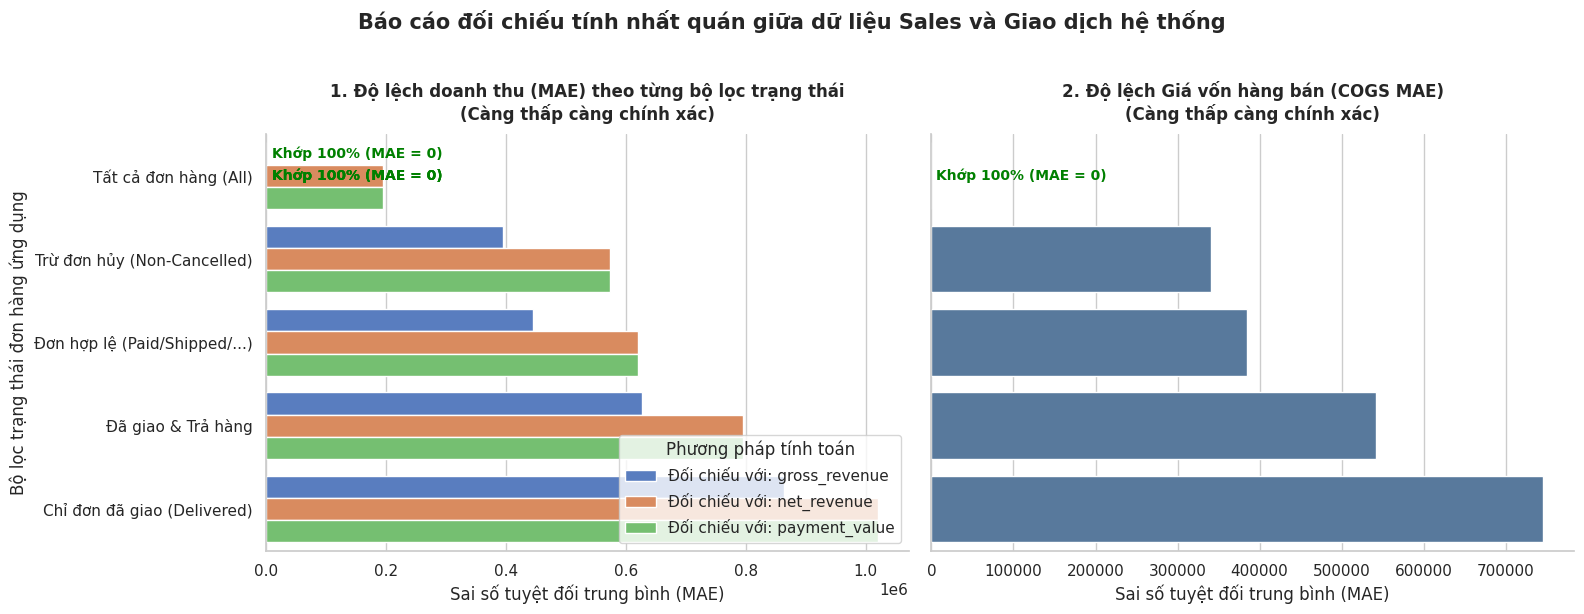

In [47]:
"""
Phần EDA: 3. Sales Reconciliation
Mục tiêu cell: Trực quan hóa độ lệch giữa sales.csv và transaction data để đánh giá sales target khớp với công thức transaction nào nhất.
"""

# 1. Tách dữ liệu thành 2 nhóm: Kiểm tra Doanh thu (Revenue) và Giá vốn (COGS)
revenue_df = sales_transaction_consistency[sales_transaction_consistency["compared_metric"].str.contains("Revenue")].copy()
cogs_df = sales_transaction_consistency[sales_transaction_consistency["compared_metric"].str.contains("calculated_cogs")].copy()

# Việt hóa tên bộ lọc để biểu đồ thân thiện hơn
vietnamese_labels = {
    "all_orders": "Tất cả đơn hàng (All)",
    "non_cancelled": "Trừ đơn hủy (Non-Cancelled)",
    "paid_shipped_delivered_returned": "Đơn hợp lệ (Paid/Shipped/...)",
    "delivered_returned": "Đã giao & Trả hàng",
    "delivered_only": "Chỉ đơn đã giao (Delivered)"
}
revenue_df["status_filter_vi"] = revenue_df["status_filter"].map(vietnamese_labels)
cogs_df["status_filter_vi"] = cogs_df["status_filter"].map(vietnamese_labels)

# Đổi tên metric so sánh cho gọn gàng trên đồ thị
revenue_df["compared_metric"] = revenue_df["compared_metric"].str.replace("sales.Revenue vs ", "Đối chiếu với: ")

# 2. Khởi tạo không gian vẽ (2 biểu đồ song song: Doanh thu và Giá vốn)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- BIỂU ĐỒ 1: ĐỐI CHIẾU DOANH THU ----
sns.barplot(
    data=revenue_df,
    x="MAE", y="status_filter_vi", hue="compared_metric",
    ax=axes[0], palette="muted"
)
axes[0].set_title("1. Độ lệch doanh thu (MAE) theo từng bộ lọc trạng thái\n(Càng thấp càng chính xác)", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("Sai số tuyệt đối trung bình (MAE)")
axes[0].set_ylabel("Bộ lọc trạng thái đơn hàng ứng dụng")
axes[0].legend(title="Phương pháp tính toán", loc="lower right")

# Ghi chú trực tiếp lên thanh biểu đồ để nhấn mạnh kết quả bằng 0
for p in axes[0].patches:
    width = p.get_width()
    if width == 0:
        axes[0].text(10000, p.get_y() + p.get_height()/2, "Khớp 100% (MAE = 0)", 
                     va="center", ha="left", color="green", fontweight="bold", fontsize=10)

# ---- BIỂU ĐỒ 2: ĐỐI CHIẾU GIÁ VỐN ----
sns.barplot(
    data=cogs_df,
    x="MAE", y="status_filter_vi", color="#4c78a8",
    ax=axes[1]
)
axes[1].set_title("2. Độ lệch Giá vốn hàng bán (COGS MAE)\n(Càng thấp càng chính xác)", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("Sai số tuyệt đối trung bình (MAE)")
axes[1].set_ylabel("") # Ẩn trục Y để tránh lặp lại chữ
axes[1].set_yticklabels([])

for p in axes[1].patches:
    width = p.get_width()
    if width == 0:
        axes[1].text(5000, p.get_y() + p.get_height()/2, "Khớp 100% (MAE = 0)", 
                     va="center", ha="left", color="green", fontweight="bold", fontsize=10)

plt.suptitle("Báo cáo đối chiếu tính nhất quán giữa dữ liệu Sales và Giao dịch hệ thống", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sales_transaction_consistency.png", dpi=300, bbox_inches="tight")
plt.show()

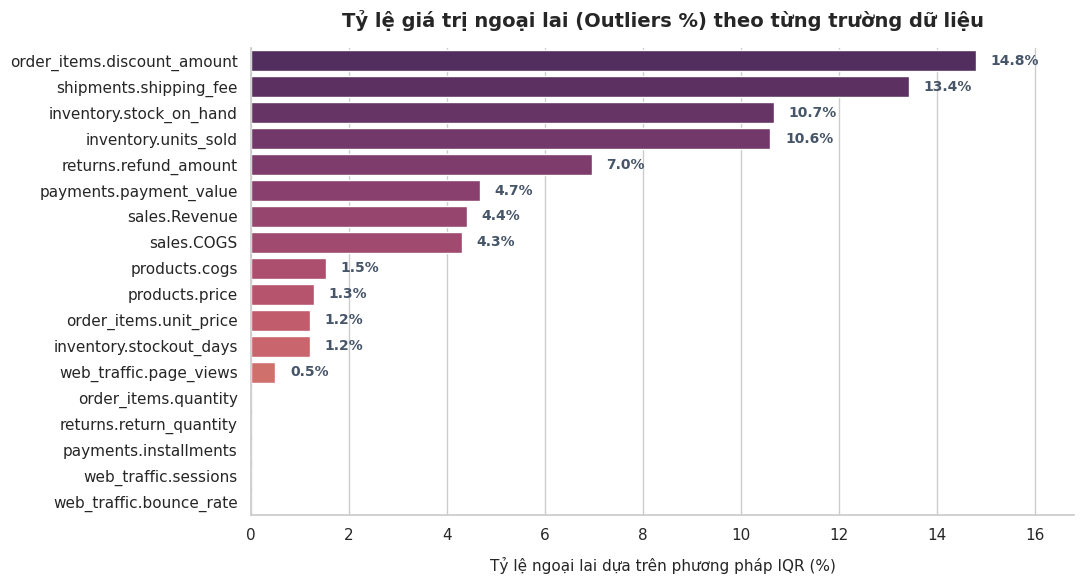

In [50]:
"""
Phần EDA: 3. Outlier Quality View
Mục tiêu cell: Vẽ tỷ lệ outlier theo từng trường numeric quan trọng để biết cột nào cần flag/investigate nhưng chưa mặc định là lỗi.
"""

# 1. Chuẩn bị dữ liệu và gộp tên Bảng + Cột để hiển thị rõ ràng
plot_df = outlier_quality_summary.copy()
plot_df["Cột dữ liệu"] = plot_df["table_name"] + "." + plot_df["column"]
plot_df = plot_df.sort_values("outlier_pct", ascending=False)

# 2. Khởi tạo không gian vẽ
plt.figure(figsize=(11, 6))

# Vẽ biểu đồ cột ngang bằng Seaborn
ax = sns.barplot(
    data=plot_df,
    x="outlier_pct", 
    y="Cột dữ liệu", 
    palette="flare_r" # Tông màu chuyển từ cam đỏ (nhiều outlier) sang nhạt dần
)

# Ghi số phần trăm cụ thể lên đầu mỗi thanh cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.3, 
            p.get_y() + p.get_height()/2, 
            f"{width:.1f}%", 
            va="center", 
            ha="left", 
            fontsize=10, 
            fontweight="bold",
            color="#475569"
        )

# 3. Tinh chỉnh tiêu đề nghiệp vụ tiếng Việt
plt.title("Tỷ lệ giá trị ngoại lai (Outliers %) theo từng trường dữ liệu", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Tỷ lệ ngoại lai dựa trên phương pháp IQR (%)", fontsize=11, labelpad=10)
plt.ylabel("", fontsize=11)
plt.xlim(0, plot_df["outlier_pct"].max() + 2) # Tạo khoảng trống bên phải để ghi chữ

plt.tight_layout()
plt.savefig("outlier_distribution_chart.png", dpi=300)
plt.show()

In [48]:
"""
Phần EDA: 3. Outlier Quality View
Mục tiêu cell: Tính outlier theo IQR cho các numeric field quan trọng, kèm percentile và quyết định xử lý ở mức data quality.
"""

outlier_specs = {
    "products": ["price", "cogs"],
    "order_items": ["quantity", "unit_price", "discount_amount"],
    "payments": ["payment_value", "installments"],
    "shipments": ["shipping_fee"],
    "returns": ["return_quantity", "refund_amount"],
    "sales": ["Revenue", "COGS"],
    "inventory": ["stock_on_hand", "units_sold", "stockout_days"],
    "web_traffic": ["sessions", "page_views", "bounce_rate"],
}

outlier_rows = []
for table, cols in outlier_specs.items():
    for col in cols:A
        if col not in tables[table].columns:
            continue
        s = pd.to_numeric(tables[table][col], errors="coerce").dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier = (s < lo) | (s > hi)
        outlier_rows.append({
            "table_name": table,
            "column": col,
            "method": "IQR",
            "lower_bound": round(lo, 3),
            "upper_bound": round(hi, 3),
            "outlier_count": int(outlier.sum()),
            "outlier_pct": round(outlier.mean() * 100, 3),
            "min": round(s.min(), 3),
            "p1": round(s.quantile(0.01), 3),
            "median": round(s.median(), 3),
            "p99": round(s.quantile(0.99), 3),
            "max": round(s.max(), 3),
            "decision": "Flag only",
            "note": "Outlier is not automatically an error",
        })

outlier_quality_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_quality_summary)

,table_name,column,method,lower_bound,upper_bound,outlier_count,outlier_pct,min,p1,median,p99,max,decision,note
4,order_items,discount_amount,IQR,-1451.445,2419.075,105767,14.799,0.000,0.000,0.000,1.104115e+04,3.523547e+04,Flag only,Outlier is not automatically an error
7,shipments,shipping_fee,IQR,-1.725,5.195,76050,13.435,0.000,0.040,1.730,3.129000e+01,3.200000e+01,Flag only,Outlier is not automatically an error
12,inventory,stock_on_hand,IQR,-277.500,502.500,6432,10.676,3.000,3.000,62.000,1.525080e+03,2.673000e+03,Flag only,Outlier is not automatically an error
13,inventory,units_sold,IQR,-19.000,37.000,6388,10.603,1.000,1.000,6.000,1.350000e+02,6.700000e+02,Flag only,Outlier is not automatically an error
9,returns,refund_amount,IQR,-16389.497,36844.882,2778,6.956,458.810,635.214,7888.880,6.667728e+04,1.609379e+05,Flag only,Outlier is not automatically an error
5,payments,payment_value,IQR,-31356.875,72744.285,30219,4.671,389.740,1052.669,17229.440,9.807575e+04,3.315704e+05,Flag only,Outlier is not automatically an error
10,sales,Revenue,IQR,-1848593.750,9670559.770,169,4.409,279813.940,845078.752,3647303.900,1.380199e+07,2.090527e+07,Flag only,Outlier is not automatically an error
11,sales,COGS,IQR,-1579490.305,8367364.455,165,4.305,236576.310,738138.756,3161112.990,1.157411e+07,1.653586e+07,Flag only,Outlier is not automatically an error
1,products,cogs,IQR,-8709.709,14609.692,37,1.534,5.184,9.847,3184.934,1.612482e+04,3.890250e+04,Flag only,Outlier is not automatically an error
0,products,price,IQR,-11432.158,19212.117,31,1.285,9.057,16.762,4399.605,1.953831e+04,4.095000e+04,Flag only,Outlier is not automatically an error


## 4. Khám phá phân phối dữ liệu

Mục tiêu: sau khi biết dữ liệu đủ ổn để đọc tiếp, ta xem phân phối số, nhóm category, nhóm nào đóng góp doanh thu lớn. Đây vẫn là mô tả dữ liệu, chưa kết luận nguyên nhân.

In [54]:
"""
Phần EDA: 4. Distribution Snapshot
Mục tiêu cell: Tóm tắt phân phối các biến numeric chính bằng mean, median, percentile, min/max và skew.
"""

numeric_cols = {
    "sales": ["Revenue", "COGS"],
    "payments": ["payment_value", "installments"],
    "order_items": ["quantity", "unit_price", "discount_amount"],
    "products": ["price", "cogs"],
    "returns": ["refund_amount", "return_quantity"],
    "reviews": ["rating"],
    "web_traffic": ["sessions", "unique_visitors", "page_views", "bounce_rate"],
    "inventory": ["stock_on_hand", "units_sold", "stockout_days", "fill_rate", "sell_through_rate"],
}

num_rows = []
sales_metrics = tables["sales"].assign(Gross_Profit=lambda d: d["Revenue"] - d["COGS"])
sales_metrics["Margin"] = sales_metrics["Gross_Profit"] / sales_metrics["Revenue"]
tables_for_distribution = dict(tables)
tables_for_distribution["sales"] = sales_metrics
numeric_cols["sales"] = ["Revenue", "COGS", "Gross_Profit", "Margin"]

for table, cols in numeric_cols.items():
    for col in cols:
        if col not in tables_for_distribution[table].columns:
            continue
        s = pd.to_numeric(tables_for_distribution[table][col], errors="coerce")
        num_rows.append({
            "table_name": table,
            "column": col,
            "count": int(s.notna().sum()),
            "mean": round(s.mean(), 3),
            "median": round(s.median(), 3),
            "min": round(s.min(), 3),
            "p25": round(s.quantile(0.25), 3),
            "p75": round(s.quantile(0.75), 3),
            "p95": round(s.quantile(0.95), 3),
            "p99": round(s.quantile(0.99), 3),
            "max": round(s.max(), 3),
            "skew": round(s.skew(), 3),
        })

numeric_distribution_summary = pd.DataFrame(num_rows)
display(numeric_distribution_summary)

,table_name,column,count,mean,median,min,p25,p75,p95,p99,max,skew
0,sales,Revenue,3833,4286584.030,3647303.900,279813.940,2471088.820,5350877.200,9398759.872,1.380199e+07,2.090527e+07,1.670
1,sales,COGS,3833,3695134.495,3161112.990,236576.310,2150580.230,4637293.920,8090775.748,1.157411e+07,1.653586e+07,1.625
2,sales,Gross_Profit,3833,591449.535,544554.380,-2567311.720,229274.050,876080.980,1706283.482,2.698726e+06,4.369414e+06,0.235
3,sales,Margin,3833,0.125,0.178,-0.575,0.083,0.203,0.225,2.440000e-01,2.870000e-01,-2.532
4,payments,payment_value,646945,24238.334,17229.440,389.740,7681.060,33706.350,70870.128,9.807575e+04,3.315704e+05,1.679
5,payments,installments,646945,3.448,3.000,1.000,1.000,6.000,12.000,1.200000e+01,1.200000e+01,1.619
6,order_items,quantity,714669,4.496,4.000,1.000,2.000,6.000,8.000,8.000000e+00,8.000000e+00,0.001
7,order_items,unit_price,714669,5114.690,4257.770,392.570,1906.890,7273.760,11912.290,1.577848e+04,4.305600e+04,1.016
8,order_items,discount_amount,714669,1048.887,0.000,0.000,0.000,967.630,5815.144,1.104115e+04,3.523547e+04,3.382
9,products,price,2412,4928.216,4399.605,9.057,59.445,7720.514,13227.984,1.953831e+04,4.095000e+04,1.330


10

In [55]:
"""
Phần EDA: 4. Distribution Snapshot
Mục tiêu cell: Tóm tắt top values của các biến categorical chính để thấy nhóm nào phổ biến và cardinality của từng cột.
"""

cat_cols = {
    "orders": ["order_status", "payment_method", "device_type", "order_source"],
    "customers": ["gender", "age_group", "acquisition_channel", "city"],
    "products": ["category", "segment", "size", "color"],
    "returns": ["return_reason"],
    "web_traffic": ["traffic_source"],
}

cat_rows = []
for table, cols in cat_cols.items():
    for col in cols:
        counts = tables[table][col].value_counts(dropna=False).head(5)
        cat_rows.append({
            "table_name": table,
            "column": col,
            "unique_values": int(tables[table][col].nunique(dropna=False)),
            "top_values": "; ".join([f"{idx}: {val} ({val / len(tables[table]) * 100:.1f}%)" for idx, val in counts.items()]),
        })

categorical_distribution_summary = pd.DataFrame(cat_rows)
display(categorical_distribution_summary)

,table_name,column,unique_values,top_values
0,orders,order_status,6,delivered: 516716 (79.9%); cancelled: 59462 (9...
1,orders,payment_method,5,credit_card: 356352 (55.1%); paypal: 97018 (15...
2,orders,device_type,3,mobile: 291482 (45.1%); desktop: 258855 (40.0%...
3,orders,order_source,6,organic_search: 181495 (28.1%); paid_search: 1...
4,customers,gender,3,Female: 59640 (48.9%); Male: 57457 (47.1%); No...
5,customers,age_group,5,25-34: 36342 (29.8%); 35-44: 31920 (26.2%); 45...
6,customers,acquisition_channel,6,organic_search: 36450 (29.9%); social_media: 2...
7,customers,city,42,Cam Pha: 4398 (3.6%); Thai Nguyen: 4347 (3.6%)...
8,products,category,4,Streetwear: 1320 (54.7%); Outdoor: 743 (30.8%)...
9,products,segment,8,Activewear: 598 (24.8%); Everyday: 405 (16.8%)...


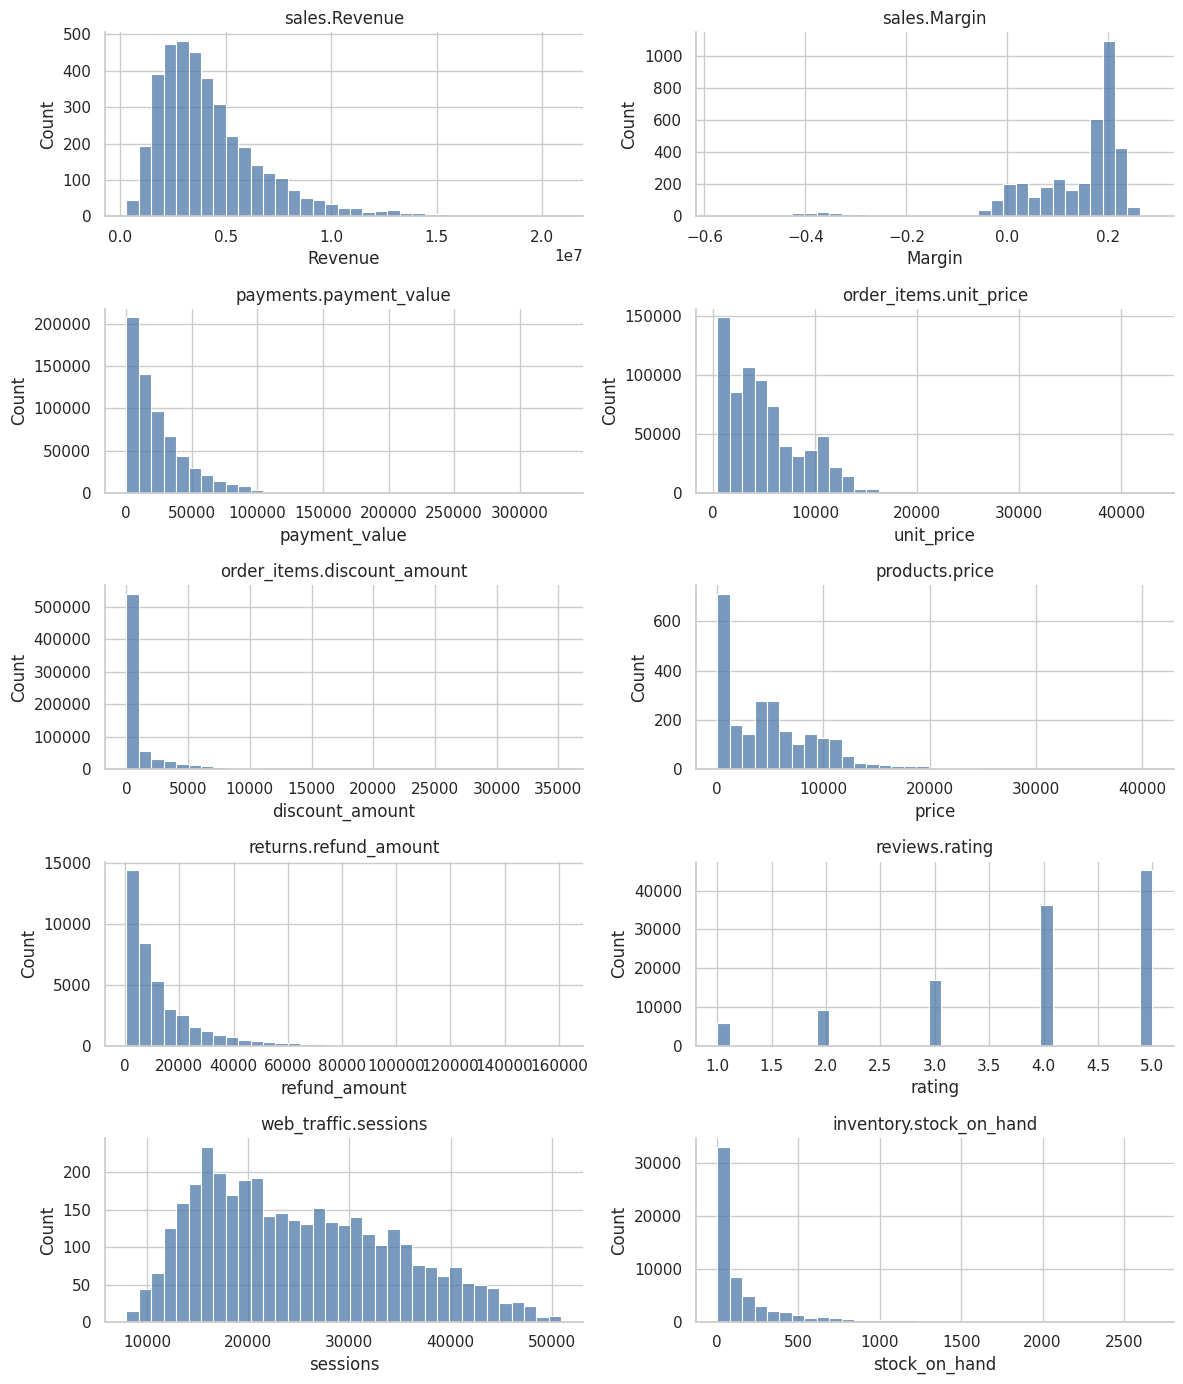

In [57]:
"""
Phần EDA: 4. Distribution Snapshot
Mục tiêu cell: Vẽ histogram grid cho các numeric field quan trọng để nhìn nhanh độ lệch, đuôi dài và thang đo của từng biến.
"""

plot_specs = [
    ("sales", "Revenue"), ("sales", "Margin"), ("payments", "payment_value"),
    ("order_items", "unit_price"), ("order_items", "discount_amount"),
    ("products", "price"), ("returns", "refund_amount"), ("reviews", "rating"),
    ("web_traffic", "sessions"), ("inventory", "stock_on_hand"),
]

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
for ax, (table, col) in zip(axes.ravel(), plot_specs):
    s = pd.to_numeric(tables_for_distribution[table][col], errors="coerce").dropna()
    sns.histplot(s, bins=35, ax=ax, color="#4c78a8")
    ax.set_title(f"{table}.{col}")
for ax in axes.ravel()[len(plot_specs):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

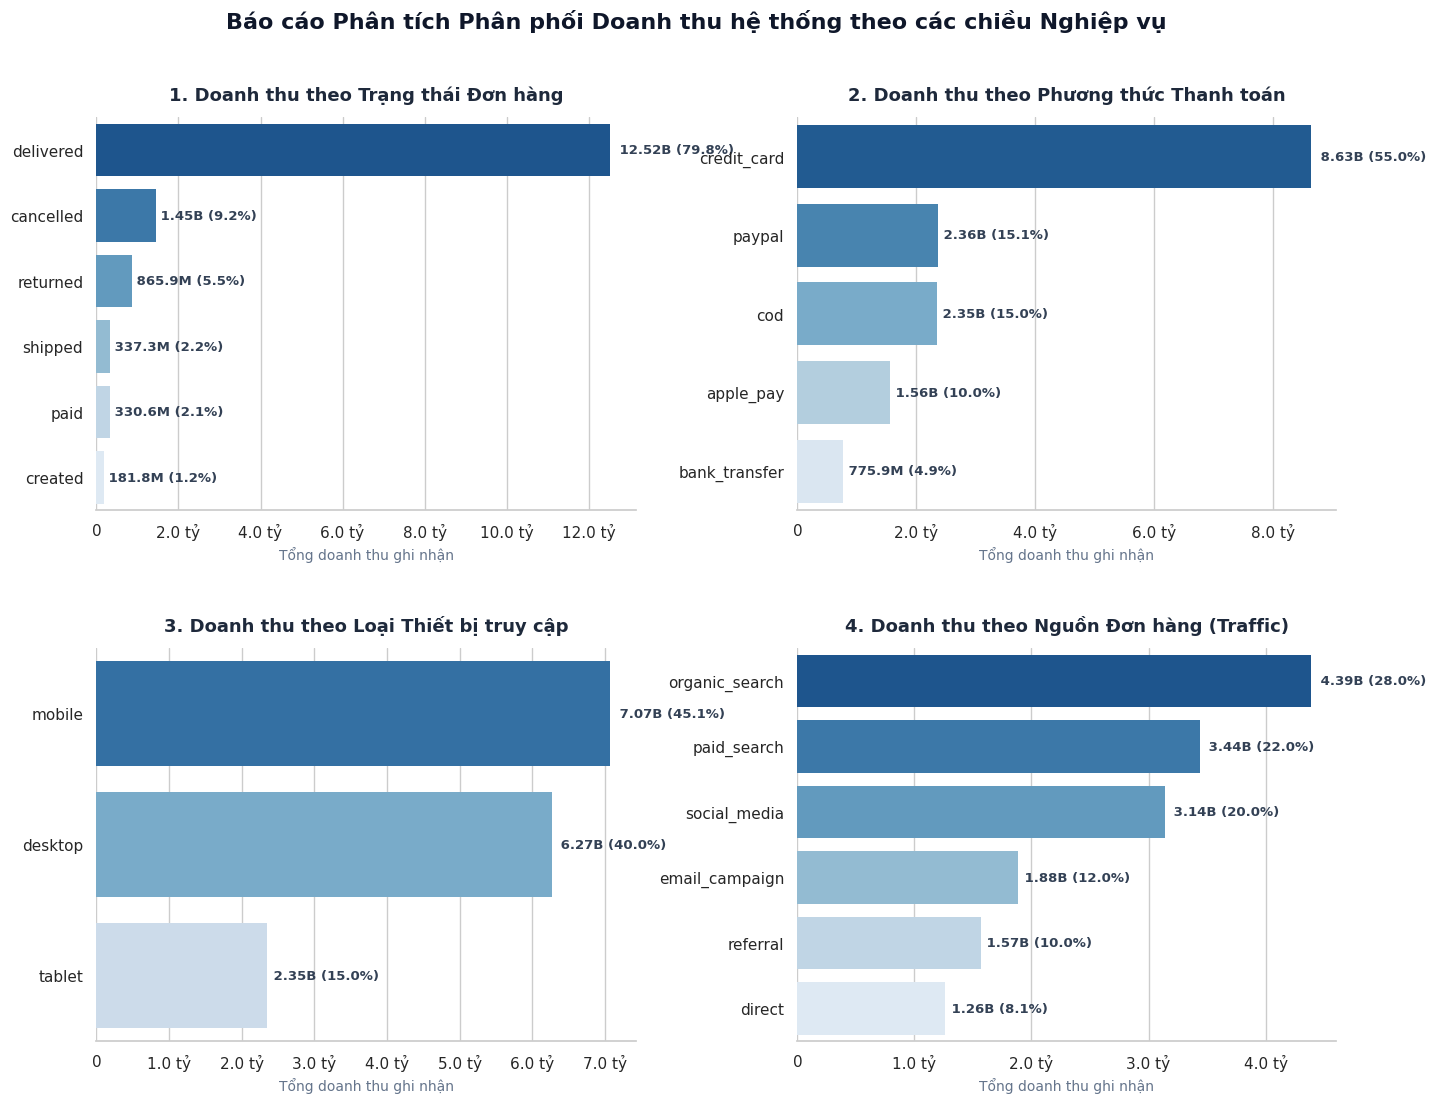

In [61]:
"""
Phần EDA: 4. Revenue by Order Dimensions
Mục tiêu cell: Vẽ doanh thu theo order_status, payment_method, device_type và order_source để hiểu nhóm/kênh nào đóng góp nhiều nhất.
"""

# 1. Khởi tạo khung vẽ ma trận biểu đồ 2 dòng x 2 cột
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# Định nghĩa danh sách các chiều và tiêu đề tương ứng để chạy vòng lặp
fields_to_plot = [
    ("order_status", "1. Doanh thu theo Trạng thái Đơn hàng"),
    ("payment_method", "2. Doanh thu theo Phương thức Thanh toán"),
    ("device_type", "3. Doanh thu theo Loại Thiết bị truy cập"),
    ("order_source", "4. Doanh thu theo Nguồn Đơn hàng (Traffic)")
]

# Hàm định dạng số tiền rút gọn thành tỷ (B) hoặc triệu (M) cho trục tọa độ
def money_formatter(x, pos):
    if x >= 1e9: return f'{x*1e-9:.1f} tỷ'
    if x >= 1e6: return f'{x*1e-6:.0f} triệu'
    return f'{x:.0f}'

# 2. Vòng lặp tự động bóc tách dữ liệu từ DataFrame gốc vẽ lên từng góc
for ax, (field_name, plot_title) in zip(axes.ravel(), fields_to_plot):
    # Lọc riêng dữ liệu của chiều hiện tại và lấy top 8 giá trị cao nhất
    sub_df = revenue_by_order_group[revenue_by_order_group["group_field"] == field_name].copy()
    sub_df = sub_df.sort_values("revenue", ascending=False).head(8)
    
    # Vẽ biểu đồ cột ngang bằng Seaborn (Tone màu xanh chuyển sắc mượt mà)
    sns.barplot(
        data=sub_df, 
        x="revenue", 
        y="group_value", 
        ax=ax, 
        palette="Blues_r",
        edgecolor="none"
    )
    
    # Tinh chỉnh tiêu đề tiếng Việt và các trục tọa độ
    ax.set_title(plot_title, fontsize=13, fontweight='bold', pad=12, color="#1e293b")
    ax.set_xlabel("Tổng doanh thu ghi nhận", fontsize=10, color="#64748b")
    ax.set_ylabel("", fontsize=10)
    ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
    
    # Loại bỏ đường viền hộp biểu đồ để nhìn thoáng đãng và hiện đại hơn
    sns.despine(ax=ax, left=True, bottom=False)
    
    # 3. Ghi thông số cụ thể (Doanh thu & Số đơn) lên trực tiếp thanh đồ thị
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if width > 0:
            # Lấy thông tin tỷ lệ % và số lượng đơn tương ứng từ dòng dữ liệu
            pct = sub_df.iloc[i]["revenue_pct"]
            ords = sub_df.iloc[i]["orders"]
            
            # Định dạng nhãn hiển thị: "Số tiền (Tỷ lệ % | Số đơn hàng)"
            if width >= 1e9: label_text = f" {width*1e-9:.2f}B ({pct:.1f}%)"
            else: label_text = f" {width*1e-6:.1f}M ({pct:.1f}%)"
            
            # Ghi chữ lên bên phải thanh cột ngang
            ax.text(
                width + (width * 0.01), 
                p.get_y() + p.get_height()/2, 
                label_text, 
                va='center', 
                ha='left', 
                fontsize=9.5, 
                fontweight='bold',
                color="#334155"
            )

# Thêm tiêu đề lớn bao quát toàn bộ báo cáo
plt.suptitle("Báo cáo Phân tích Phân phối Doanh thu hệ thống theo các chiều Nghiệp vụ", 
             fontsize=16, fontweight='bold', y=0.97, color="#0f172a")

# Lưu và hiển thị hình ảnh chuẩn quy trình Kaggle
plt.savefig("revenue_distribution_by_dimensions.png", dpi=300, bbox_inches="tight")
plt.show()

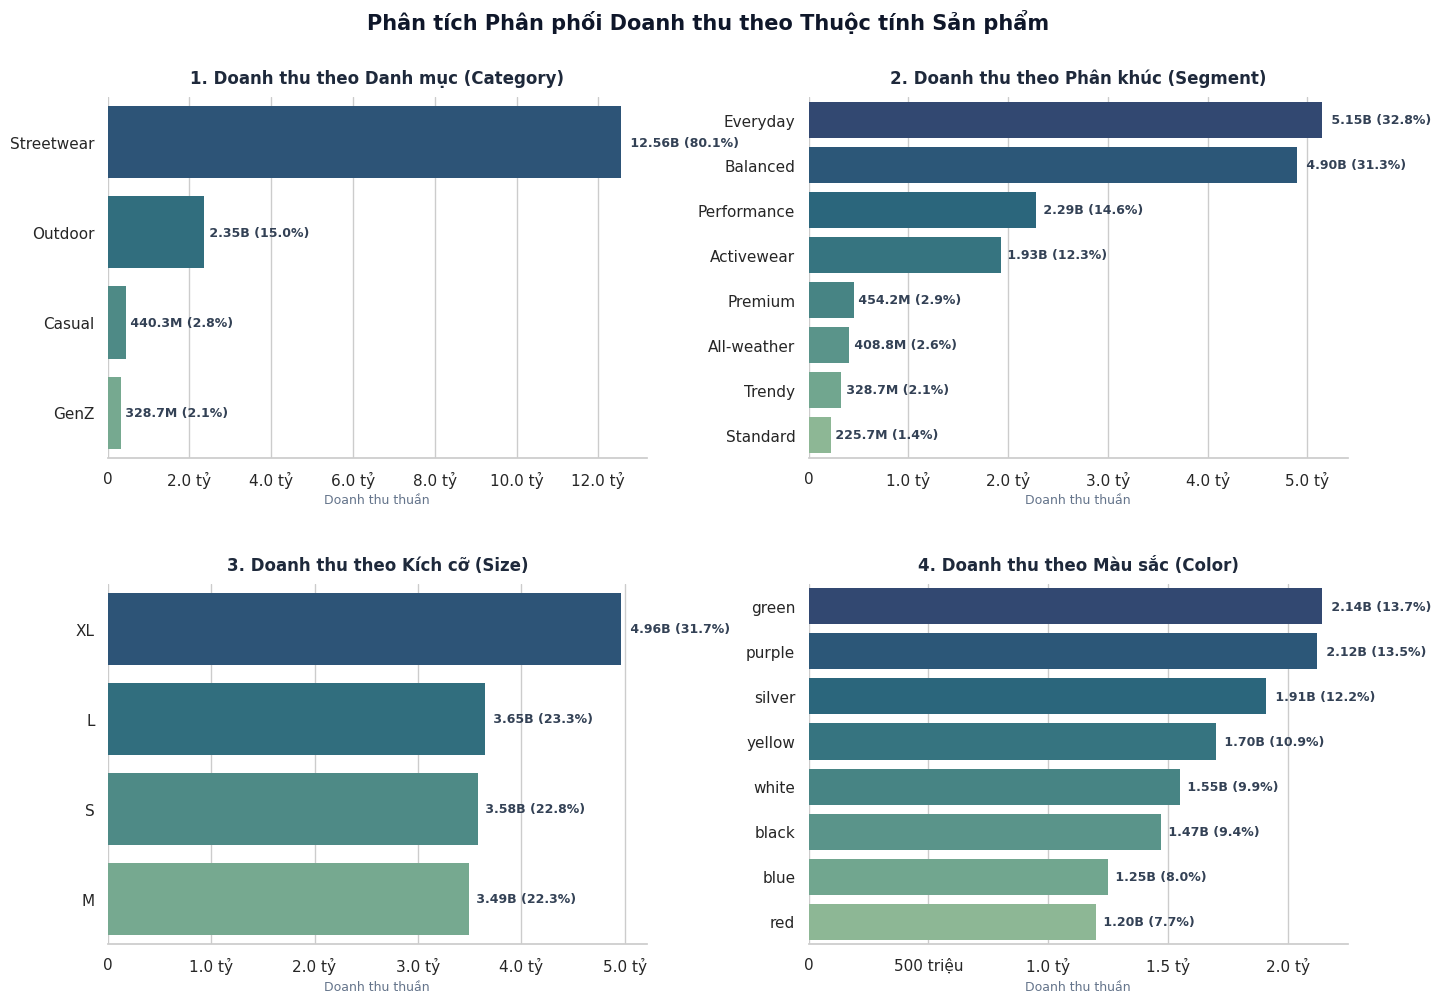

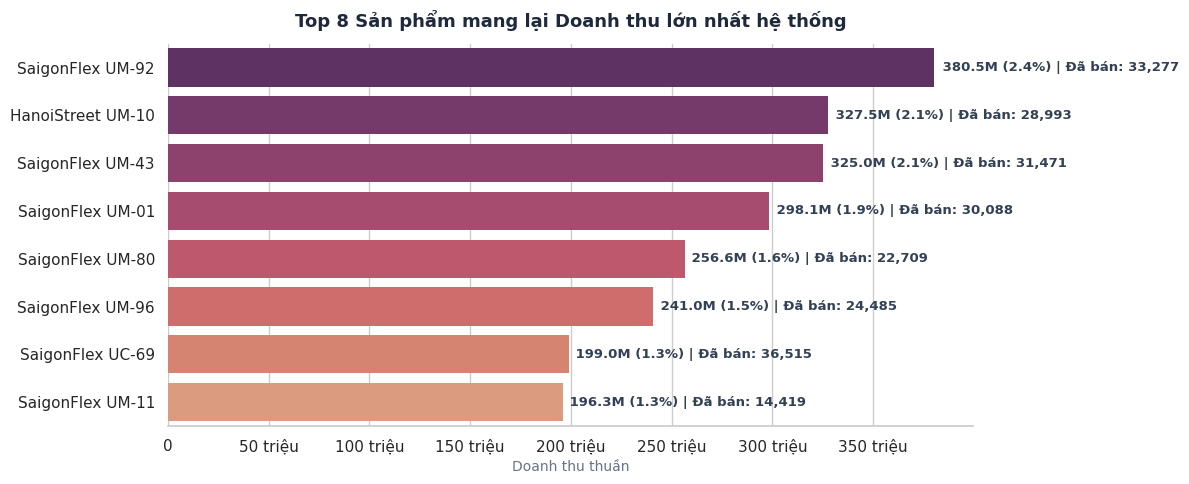

In [62]:
"""
Phần EDA: 4. Revenue by Product Dimensions
Mục tiêu cell: Vẽ doanh thu theo category, segment, size và color để hiểu cơ cấu sản phẩm đóng góp vào revenue.
"""

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Hàm định dạng tiền tệ rút gọn (Tỷ/Triệu)
def money_formatter(x, pos):
    if x >= 1e9: return f'{x*1e-9:.1f} tỷ'
    if x >= 1e6: return f'{x*1e-6:.0f} triệu'
    return f'{x:.0f}'

# =====================================================================
# BIỂU ĐỒ 1: MA TRẬN 2x2 CHO CÁC THUỘC TÍNH SẢN PHẨM (Category, Segment, Size, Color)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

fields_to_plot = [
    ("category", "1. Doanh thu theo Danh mục (Category)"),
    ("segment", "2. Doanh thu theo Phân khúc (Segment)"),
    ("size", "3. Doanh thu theo Kích cỡ (Size)"),
    ("color", "4. Doanh thu theo Màu sắc (Color)")
]

for ax, (field_name, plot_title) in zip(axes.ravel(), fields_to_plot):
    # Lọc dữ liệu theo từng nhóm và lấy top 8
    sub_df = revenue_by_product_group[revenue_by_product_group["group_field"] == field_name].copy()
    sub_df = sub_df.sort_values("revenue", ascending=False).head(8)
    
    # Vẽ biểu đồ cột ngang (Dùng palette màu sắc ấm áp 'flare_r' hoặc 'crest_r' để phân biệt với phần đơn hàng)
    sns.barplot(data=sub_df, x="revenue", y="group_value", ax=ax, palette="crest_r", edgecolor="none")
    
    ax.set_title(plot_title, fontsize=12, fontweight='bold', pad=10, color="#1e293b")
    ax.set_xlabel("Doanh thu thuần", fontsize=9, color="#64748b")
    ax.set_ylabel("", fontsize=10)
    ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
    sns.despine(ax=ax, left=True, bottom=False)
    
    # Ghi chú % doanh thu và số lượng sản phẩm trực tiếp lên cột
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if width > 0:
            pct = sub_df.iloc[i]["revenue_pct"]
            prod_cnt = sub_df.iloc[i]["products"]
            
            if width >= 1e9: label_text = f" {width*1e-9:.2f}B ({pct:.1f}%)"
            else: label_text = f" {width*1e-6:.1f}M ({pct:.1f}%)"
            
            ax.text(width + (width * 0.01), p.get_y() + p.get_height()/2, label_text, 
                    va='center', ha='left', fontsize=9, fontweight='bold', color="#334155")

plt.suptitle("Phân tích Phân phối Doanh thu theo Thuộc tính Sản phẩm", fontsize=15, fontweight='bold', y=0.96, color="#0f172a")
plt.savefig("product_attributes_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================================
# BIỂU ĐỒ 2: TOP 8 SẢN PHẨM CÓ DOANH THU CAO NHẤT (Product Name)
# =====================================================================
plt.figure(figsize=(12, 5))

# Lọc riêng dữ liệu tên sản phẩm
product_df = revenue_by_product_group[revenue_by_product_group["group_field"] == "product_name"].copy()
product_df = product_df.sort_values("revenue", ascending=False).head(8)

ax2 = sns.barplot(data=product_df, x="revenue", y="group_value", palette="flare_r", edgecolor="none")

plt.title("Top 8 Sản phẩm mang lại Doanh thu lớn nhất hệ thống", fontsize=13, fontweight='bold', pad=12, color="#1e293b")
plt.xlabel("Doanh thu thuần", fontsize=10, color="#64748b")
plt.ylabel("", fontsize=10)
ax2.xaxis.set_major_formatter(FuncFormatter(money_formatter))
sns.despine(ax=ax2, left=True, bottom=False)

# Ghi chú chi tiết lên thanh sản phẩm
for i, p in enumerate(ax2.patches):
    width = p.get_width()
    if width > 0:
        pct = product_df.iloc[i]["revenue_pct"]
        qty = product_df.iloc[i]["quantity"] # Lấy thêm số lượng đã bán ra
        
        if width >= 1e9: label_text = f" {width*1e-9:.2f}B ({pct:.1f}%) | Đã bán: {int(qty):,}"
        else: label_text = f" {width*1e-6:.1f}M ({pct:.1f}%) | Đã bán: {int(qty):,}"
        
        ax2.text(width + (width * 0.005), p.get_y() + p.get_height()/2, label_text, 
                 va='center', ha='left', fontsize=9.5, fontweight='bold', color="#334155")

plt.tight_layout()
plt.savefig("top_products_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Khám phá theo thời gian

Mục tiêu: kiểm tra dữ liệu có đủ ngày liên tục không, revenue/COGS/profit thay đổi thế nào theo ngày-tháng-năm, và các bảng vận hành như orders, returns, web traffic, inventory có pattern thời gian không.

In [ ]:
"""
Phần EDA: 5. Time Coverage
Mục tiêu cell: Kiểm tra coverage thời gian của các bảng có ngày, gồm min/max date, unique dates và số ngày thiếu giữa min-max.
"""

time_coverage_rows = []
for table, col in {
    "sales": "Date",
    "sample_submission": "Date",
    "orders": "order_date",
    "returns": "return_date",
    "reviews": "review_date",
    "web_traffic": "date",
    "inventory": "snapshot_date",
}.items():
    df = tables[table]
    dates = df[col].dropna()
    all_days = pd.date_range(dates.min().normalize(), dates.max().normalize(), freq="D")
    present_days = pd.Index(dates.dt.normalize().unique())
    time_coverage_rows.append({
        "table_name": table,
        "date_column": col,
        "rows": len(df),
        "min_date": dates.min(),
        "max_date": dates.max(),
        "unique_dates": int(present_days.nunique()),
        "expected_days_between_min_max": len(all_days),
        "missing_days_between_min_max": int(len(all_days.difference(present_days))),
    })

time_coverage_summary = pd.DataFrame(time_coverage_rows)
display(time_coverage_summary)

In [ ]:
"""
Phần EDA: 5. Daily Sales Trend
Mục tiêu cell: Tạo bảng sales theo ngày với Gross Profit, Margin và rolling average 7/30 ngày để chuẩn bị xem trend.
"""

sales_daily = tables["sales"].sort_values("Date").copy()
sales_daily["Gross_Profit"] = sales_daily["Revenue"] - sales_daily["COGS"]
sales_daily["Margin"] = sales_daily["Gross_Profit"] / sales_daily["Revenue"]
sales_daily["Revenue_rolling_7d"] = sales_daily["Revenue"].rolling(7, min_periods=1).mean()
sales_daily["Revenue_rolling_30d"] = sales_daily["Revenue"].rolling(30, min_periods=1).mean()

display(sales_daily.tail(15))

In [ ]:
"""
Phần EDA: 5. Daily Sales Trend
Mục tiêu cell: Vẽ daily Revenue cùng rolling 7 ngày và 30 ngày để tách nhiễu ngày lẻ khỏi xu hướng chính.
"""

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(sales_daily["Date"], sales_daily["Revenue"], linewidth=0.5, alpha=0.22, color="#64748b", label="Daily Revenue")
ax.plot(sales_daily["Date"], sales_daily["Revenue_rolling_7d"], linewidth=1.1, color="#f97316", label="7d rolling")
ax.plot(sales_daily["Date"], sales_daily["Revenue_rolling_30d"], linewidth=2.0, color="#2563eb", label="30d rolling")
ax.set_title("Daily Revenue with rolling averages")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Monthly Sales Trend
Mục tiêu cell: Tổng hợp Revenue, COGS, Gross Profit, Margin theo tháng và tính tăng trưởng MoM.
"""

sales_monthly = sales_daily.assign(month=month_start(sales_daily["Date"])).groupby("month", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    Gross_Profit=("Gross_Profit", "sum"),
    Margin=("Margin", "mean"),
    days_observed=("Date", "nunique"),
)
sales_monthly["Revenue_mom_pct"] = sales_monthly["Revenue"].pct_change() * 100
display(sales_monthly.tail(18))

In [ ]:
"""
Phần EDA: 5. Monthly Sales Trend
Mục tiêu cell: Vẽ monthly Revenue, COGS, Gross Profit và Margin để xem mùa vụ, tháng giảm mạnh và tháng margin âm.
"""

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(sales_monthly["month"], sales_monthly["Revenue"], label="Revenue", color="#2563eb", linewidth=2)
ax1.plot(sales_monthly["month"], sales_monthly["COGS"], label="COGS", color="#f97316", linewidth=1.8)
ax1.set_title("Monthly Revenue, COGS, Gross Profit, and Margin")
ax1.set_ylabel("Revenue / COGS")
ax1.yaxis.set_major_formatter(FuncFormatter(compact_number))
ax1.legend()
colors = np.where(sales_monthly["Gross_Profit"] >= 0, "#16a34a", "#dc2626")
ax2.bar(sales_monthly["month"], sales_monthly["Gross_Profit"], width=22, color=colors, alpha=0.75, label="Gross Profit")
ax2.axhline(0, color="#334155", linewidth=0.8)
ax2b = ax2.twinx()
ax2b.plot(sales_monthly["month"], sales_monthly["Margin"] * 100, color="#7c3aed", linewidth=1.6, label="Margin %")
ax2.set_ylabel("Gross Profit")
ax2b.set_ylabel("Margin (%)")
ax2.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Yearly Sales Trend
Mục tiêu cell: Tổng hợp sales theo năm để nhìn xu hướng dài hạn và tăng trưởng YoY.
"""

sales_yearly = sales_daily.assign(year=sales_daily["Date"].dt.year).groupby("year", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    Gross_Profit=("Gross_Profit", "sum"),
    Margin=("Margin", "mean"),
    days_observed=("Date", "nunique"),
)
sales_yearly["Revenue_yoy_pct"] = sales_yearly["Revenue"].pct_change() * 100
display(sales_yearly)

In [ ]:
"""
Phần EDA: 5. Order Status Over Time
Mục tiêu cell: Vẽ số đơn hàng theo tháng và trạng thái để xem volume/order lifecycle thay đổi theo thời gian.
"""

orders_monthly = tables["orders"].assign(month=month_start(tables["orders"]["order_date"]))
orders_status_monthly = orders_monthly.groupby(["month", "order_status"], as_index=False).agg(orders=("order_id", "nunique"))
pivot_orders = orders_status_monthly.pivot(index="month", columns="order_status", values="orders").fillna(0)

fig, ax = plt.subplots(figsize=(13, 4.8))
pivot_orders.plot(ax=ax, linewidth=1.5)
ax.set_title("Monthly orders by status")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Return Trend
Mục tiêu cell: Tạo bảng return activity rate theo tháng để theo dõi áp lực trả hàng so với số order.
"""

orders_by_month = tables["orders"].assign(month=month_start(tables["orders"]["order_date"]))
orders_by_month = orders_by_month.groupby("month", as_index=False).agg(orders=("order_id", "nunique"))

returns_by_month = tables["returns"].assign(month=month_start(tables["returns"]["return_date"]))
returns_by_month = returns_by_month.groupby("month", as_index=False).agg(
    return_rows=("return_id", "nunique"),
    returned_orders=("order_id", "nunique"),
    returned_quantity=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
)

return_rate_monthly = orders_by_month.merge(returns_by_month, on="month", how="left").fillna(0)
return_rate_monthly["return_activity_rate_pct"] = return_rate_monthly["returned_orders"] / return_rate_monthly["orders"] * 100
display(return_rate_monthly.tail(18))

In [ ]:
"""
Phần EDA: 5. Return Trend
Mục tiêu cell: Vẽ tỷ lệ đơn bị return theo tháng để phát hiện giai đoạn return bất thường.
"""

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(return_rate_monthly["month"], return_rate_monthly["return_activity_rate_pct"], color="#2563eb", linewidth=2)
ax.scatter(return_rate_monthly["month"], return_rate_monthly["return_activity_rate_pct"], color="#2563eb", s=14)
ax.set_title("Monthly return activity rate")
ax.set_xlabel("Month")
ax.set_ylabel("Returned orders / orders (%)")
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Web Traffic Trend
Mục tiêu cell: Tổng hợp và vẽ web sessions theo ngày/tháng để xem traffic có xu hướng hoặc mùa vụ rõ không.
"""

web_daily = tables["web_traffic"].groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
)
web_daily["sessions_rolling_30d"] = web_daily["sessions"].rolling(30, min_periods=1).mean()
web_monthly = web_daily.assign(month=month_start(web_daily["date"])).groupby("month", as_index=False).agg(sessions=("sessions", "sum"))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
axes[0].plot(web_daily["date"], web_daily["sessions"], linewidth=0.5, alpha=0.25, color="#64748b", label="daily")
axes[0].plot(web_daily["date"], web_daily["sessions_rolling_30d"], linewidth=2, color="#2563eb", label="30d rolling")
axes[0].set_title("Daily web sessions")
axes[0].legend()
axes[1].plot(web_monthly["month"], web_monthly["sessions"], linewidth=1.8, color="#f97316")
axes[1].scatter(web_monthly["month"], web_monthly["sessions"], s=14, color="#f97316")
axes[1].set_title("Monthly web sessions")
for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Inventory Trend
Mục tiêu cell: Tổng hợp và vẽ fill rate/sell-through rate theo tháng để xem sức khỏe vận hành inventory.
"""

inventory_monthly = tables["inventory"].assign(month=month_start(tables["inventory"]["snapshot_date"])).groupby("month", as_index=False).agg(
    stock_on_hand=("stock_on_hand", "sum"),
    units_sold=("units_sold", "sum"),
    stockout_days=("stockout_days", "sum"),
    fill_rate=("fill_rate", "mean"),
    sell_through_rate=("sell_through_rate", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axes[0].plot(inventory_monthly["month"], inventory_monthly["fill_rate"] * 100, color="#2563eb", linewidth=2)
axes[0].set_title("Monthly inventory fill rate")
axes[0].set_ylabel("Fill rate (%)")
axes[1].plot(inventory_monthly["month"], inventory_monthly["sell_through_rate"] * 100, color="#f97316", linewidth=2)
axes[1].set_title("Monthly sell-through rate")
axes[1].set_ylabel("Sell-through (%)")
axes[1].set_xlabel("Month")
plt.tight_layout()
plt.show()

In [ ]:
"""
Phần EDA: 5. Leakage Awareness
Mục tiêu cell: Liệt kê các nguồn biến có nguy cơ leakage nếu dùng cho forecast/modeling và cách dùng an toàn hơn.
"""

leakage_risk_table = pd.DataFrame([
    ["sales.Revenue / sales.COGS", "target", "future target values are unknown", "HIGH", "Use only as y, not as future feature"],
    ["orders.order_status", "transaction status", "final status may be known after order lifecycle completes", "MEDIUM", "Use carefully by forecast date"],
    ["returns.return_date / refund_amount", "post-order outcome", "returns happen after sale", "HIGH", "Use lagged aggregates only"],
    ["reviews.rating / review_date", "post-order feedback", "reviews happen after delivery", "HIGH", "Use lagged aggregates only"],
    ["web_traffic lag/rolling sessions", "demand signal", "safe if computed from past dates only", "LOW", "Good candidate for later modeling"],
    ["promotions calendar", "planned business input", "safe only if campaign plan known before forecast", "MEDIUM", "Use known future promos or lagged promo mix"],
    ["inventory snapshot", "operational state", "same-day future snapshot may not be known", "MEDIUM", "Use previous snapshot or lagged aggregates"],
], columns=["feature_source", "type", "why_risk", "leakage_risk", "safe_decision"])

display(leakage_risk_table)

## Kết luận tạm thời

Notebook đã hoàn thành các phần trong `task.md` đến **khám phá theo thời gian**:

- Đã hiểu được bảng nào là master, transaction, analytical, operational.
- Đã kiểm tra missing, duplicate, key, FK, logic thời gian, rule nghiệp vụ, lifecycle đơn hàng và consistency giữa `sales.csv` với transaction.
- Đã tạo issue log để biết vấn đề nào chỉ cần ghi chú, vấn đề nào nên điều tra sau.
- Đã khám phá phân phối doanh thu, nhóm sản phẩm/kênh bán hàng và trend ngày-tháng-năm.
- Notebook dừng trước phần phân tích mối quan hệ giữa các biến; phần tiếp theo mới nên hỏi các câu như traffic có đi cùng revenue không, discount liên quan profit thế nào, lead time có ảnh hưởng rating không.